#Libraries

In [6]:
# 1. Core Data Libraries
import pandas as pd
import numpy as np
import json
from datetime import datetime

# 2. Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import datetime as dt
import re
import nltk
from wordcloud import WordCloud

nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')
import warnings
warnings.filterwarnings('ignore')

import kagglehub
import os
import missingno as msno
from scipy.stats import skew, kurtosis
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import RobustScaler
from scipy.stats.mstats import winsorize


print("All required libraries for Dataset 2 analysis have been imported successfully!")

# ============================================================================
# CONFIGURATIONS & STYLES
# ============================================================================

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)

# Professional Color Palette
COLOR_PALETTE = {
    'primary': '#2C3E50',      # Dark Blue-Gray
    'secondary': '#E74C3C',    # Red
    'accent1': '#3498DB',      # Blue
    'accent2': '#2ECC71',      # Green
    'accent3': '#F39C12',      # Orange
    'accent4': '#9B59B6',      # Purple
    'neutral': '#95A5A6',      # Gray
    'background': '#ECF0F1'    # Light Gray
}

# Set consistent style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette([COLOR_PALETTE['accent1'], COLOR_PALETTE['secondary'],
                 COLOR_PALETTE['accent2'], COLOR_PALETTE['accent3']])

All required libraries for Dataset 2 analysis have been imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#Loading Dataset

In [7]:
print('Downloading dataset from Kaggle...')
# The dataset reference is 'olistbr/brazilian-ecommerce'
dataset_path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')

print(f"Dataset downloaded to: {dataset_path}")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Dataset downloaded to: /kaggle/input/brazilian-ecommerce


In [8]:
# ===========================================================================
# Downloaded Each Table from Dataset Step by Step.
#
# This is Structure of Workflow Ecosystem:
# (Customer --> Olist --> Sellers)
#
# This is Tabels Connect Each Others.
# (9 - Files _CSV_)
#
# (Customer --> Order --> Order_items --> Sellers --> Product --> Geolocation)
#
# (Order_Payment --> Order_Review --> Product_Category)
#
# ===========================================================================

# 1. Customer.
df_customers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")


# 2. Order.
df_orders = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv")


# 3. Order_Payment.
df_payments = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv")


# 4. Order_items.
df_items = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")

# ===========================================================================

# 5. Products.
df_products = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv")


# 6. Product_Category.
df_category = pd.read_csv("/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv")


# 7. Sellers.
df_sellers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv")

# ===========================================================================

# 8. GeoLocation. of Both (Customers - Sellers)
df_geolocation = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv")



# 9. Order_Reviews.
df_reviews = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")

# ===========================================================================

# **Check Shapes of Each Table `(9 - Tables)`**

## **`Data Overview` - Function**

In [9]:
# ==========================================
# Chunk 1: Import Display Tool for beautiful tables
# ==========================================
from IPython.display import display

# ==========================================
# Chunk 2: Define the overview function
# ==========================================
def data_overview(df, table_name="Dataset"):
    """
    This function takes a pandas DataFrame and its name as input,
    and prints a beautifully formatted summary including Shape, Info, and Head.
    """

    # 1. Print the header of the report
    print(f"\n{'='*70}")
    print(f"--> OVERVIEW REPORT FOR: {table_name.upper()}")
    print(f"{'='*70}\n")

    # 2. Extract and print the Shape (Rows & Columns)
    print("--> 1. SHAPE:")
    print(f"Total Rows: {df.shape[0]:,} | Total Columns: {df.shape[1]}")
    print("-" * 70, "\n")

    # 3. Print DataFrame Info (Data types & Non-Null counts)
    print("--> 2. INFO (Data Types & Missing Values):")
    df.info()
    print("-" * 70, "\n")

    # 4. Display the first 5 rows
    print("--> 3. FIRST 5 ROWS:")
    display(df.head())
    print(f"{'='*70}\n")

# ==========================================
# Chunk 3: How to test/use the function (Example)
# ==========================================
# Assuming you have a dataframe called df_customers
# data_overview(df_customers, "Customers Table")

## **1. `Customers` - Table**

In [10]:
# ============================================================================
# 1. Customers
# ============================================================================

data_overview(df_customers, "Customers Table")

# ============================================================================


--> OVERVIEW REPORT FOR: CUSTOMERS TABLE

--> 1. SHAPE:
Total Rows: 99,441 | Total Columns: 5
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
---------------------------------------------------------------------- 

--> 3. FIRST 5 ROWS:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## **2. `Orders` - Table**

In [11]:
# ============================================================================
# 2. Order.
# ============================================================================

data_overview(df_orders, "Orders Table")

# ============================================================================


--> OVERVIEW REPORT FOR: ORDERS TABLE

--> 1. SHAPE:
Total Rows: 99,441 | Total Columns: 8
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
------------------------------------------------------

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## **3. `Order_Payment` - Table**

In [12]:
# ============================================================================
# 3 Order_Payment.
# ============================================================================

data_overview(df_payments, "Order_Payment Table")

# ============================================================================


--> OVERVIEW REPORT FOR: ORDER_PAYMENT TABLE

--> 1. SHAPE:
Total Rows: 103,886 | Total Columns: 5
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
---------------------------------------------------------------------- 

--> 3. FIRST 5 ROWS:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## **4. `Order_Items` - Table**

In [13]:
# ============================================================================
# 4. Order_Items.
# ============================================================================

data_overview(df_items, "Order_Items Table")

# ============================================================================


--> OVERVIEW REPORT FOR: ORDER_ITEMS TABLE

--> 1. SHAPE:
Total Rows: 112,650 | Total Columns: 7
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
---------------------------------------------------------------------- 

--> 3. FIRST 5 ROWS:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## **5. `Product` - Table**

In [14]:
# ============================================================================
# 5. Product.
# ============================================================================

data_overview(df_products, "Product Table")

# ============================================================================


--> OVERVIEW REPORT FOR: PRODUCT TABLE

--> 1. SHAPE:
Total Rows: 32,951 | Total Columns: 9
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
----

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


## **6. `Product_Category` - Table**

In [15]:
# ============================================================================
# 6. Product_Category.
# ============================================================================

data_overview(df_category, "Product_Category Table")

# ============================================================================


--> OVERVIEW REPORT FOR: PRODUCT_CATEGORY TABLE

--> 1. SHAPE:
Total Rows: 71 | Total Columns: 2
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
---------------------------------------------------------------------- 

--> 3. FIRST 5 ROWS:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## **7. `Sellers` - Table**

In [16]:
# ============================================================================
# 7. Sellers.
# ============================================================================

data_overview(df_sellers, "Sellers Table")

# ============================================================================


--> OVERVIEW REPORT FOR: SELLERS TABLE

--> 1. SHAPE:
Total Rows: 3,095 | Total Columns: 4
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
---------------------------------------------------------------------- 

--> 3. FIRST 5 ROWS:


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## **8. `Geolocation` - Table**

In [17]:
# ============================================================================
# 8. Geolocation.
# ============================================================================

data_overview(df_geolocation, "Geolocation Table")

# ============================================================================


--> OVERVIEW REPORT FOR: GEOLOCATION TABLE

--> 1. SHAPE:
Total Rows: 1,000,163 | Total Columns: 5
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB
---------------------------------------------------------------------- 

--> 3. FIRST 5 ROWS:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


## **9. `Order_Review` - Table**

In [18]:
# ============================================================================
# 9. Order_Review.
# ============================================================================

data_overview(df_reviews, "Order_Review Table")

# ============================================================================


--> OVERVIEW REPORT FOR: ORDER_REVIEW TABLE

--> 1. SHAPE:
Total Rows: 99,224 | Total Columns: 7
---------------------------------------------------------------------- 

--> 2. INFO (Data Types & Missing Values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
---------------------------------------------------------------------- 

--> 3. FIRST 5 ROWS:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


#Merging datasetand and integration

In [19]:
# 1. Pre-aggregate the one-to-many tables to the 'order_id' level
# to prevent duplicate rows (Cartesian explosion).

# Aggregate both numeric scores and text comments
# We average the score, and combine any text comments together using a separator
agg_rules = {
    'review_score': 'mean',
    'review_comment_title': lambda x: ' | '.join(x.dropna().astype(str)),
    'review_comment_message': lambda x: ' | '.join(x.dropna().astype(str))
}

reviews_agg = df_reviews.groupby('order_id', as_index=False).agg(agg_rules)

# Clean up empty strings created by the join back to actual NaNs
# (This makes your 'handling missing variables' phase easier later)
import numpy as np
reviews_agg['review_comment_title'] = reviews_agg['review_comment_title'].replace('', np.nan)
reviews_agg['review_comment_message'] = reviews_agg['review_comment_message'].replace('', np.nan)


# 2. Build the base table (Order-Level) using LEFT joins
df = df_orders.merge(df_customers, on='customer_id', how='left')

df = df.merge(df_payments, on='order_id', how='left')

df = df.merge(reviews_agg, on='order_id', how='left')

# (Order --> Customers --> Payments --> Review )


# 3. Add Item-Level details (This shifts the grain of your dataset from Order to Order-Item)

df = df.merge(df_items, on='order_id', how='inner')


df = df.merge(df_products, on='product_id', how='left')


df = df.merge(df_sellers, on='seller_id', how='left')

# (Items --> Product ---> Sellers)

# Geolocation Impooortanttt ******

In [20]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_score,review_comment_title,review_comment_message,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,credit_card,1.00,18.12,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.00,voucher,1.00,2.00,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.00,voucher,1.00,18.59,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,boleto,1.00,141.46,4.00,Muito boa a loja,Muito bom o produto.,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,credit_card,3.00,179.12,5.00,NaN,NaN,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,14840,guariba,SP


In [21]:
# =========================================================================
# Data Info for Finall (df)
# =========================================================================

print("=" * 60, "\n")

print(df.info())

# =========================================================================


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117604 entries, 0 to 117603
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117604 non-null  object 
 1   customer_id                    117604 non-null  object 
 2   order_status                   117604 non-null  object 
 3   order_purchase_timestamp       117604 non-null  object 
 4   order_approved_at              117589 non-null  object 
 5   order_delivered_carrier_date   116359 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  117604 non-null  object 
 8   customer_unique_id             117604 non-null  object 
 9   customer_zip_code_prefix       117604 non-null  int64  
 10  customer_city                  117604 non-null  object 
 11  customer_state                 117604 non-null  object 
 12  payment_sequential           

#**EDA** before cleaning

In [22]:
df.shape  # structure of data

(117604, 36)

In [23]:
# check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117604 entries, 0 to 117603
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117604 non-null  object 
 1   customer_id                    117604 non-null  object 
 2   order_status                   117604 non-null  object 
 3   order_purchase_timestamp       117604 non-null  object 
 4   order_approved_at              117589 non-null  object 
 5   order_delivered_carrier_date   116359 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  117604 non-null  object 
 8   customer_unique_id             117604 non-null  object 
 9   customer_zip_code_prefix       117604 non-null  int64  
 10  customer_city                  117604 non-null  object 
 11  customer_state                 117604 non-null  object 
 12  payment_sequential            

In [24]:
# Ensure timestamps are in datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Create useful features from order_purchase_timestamp
df['day_of_week_int'] = df['order_purchase_timestamp'].dt.weekday + 1  # Day of week as integer (1 = Monday, etc.)
df['hour'] = df['order_purchase_timestamp'].dt.hour                    # Hour of day
df['month'] = df['order_purchase_timestamp'].dt.month                  # Month as integer
df['year'] = df['order_purchase_timestamp'].dt.year                    # Year as integer
df['date'] = df['order_purchase_timestamp'].dt.to_period('M')          # Monthly period for time series analysis



In [25]:
# Renaming the column to correct the spelling
df.rename(columns={'product_name_lenght': 'product_name_length'}, inplace=True)

#Missing values analysis

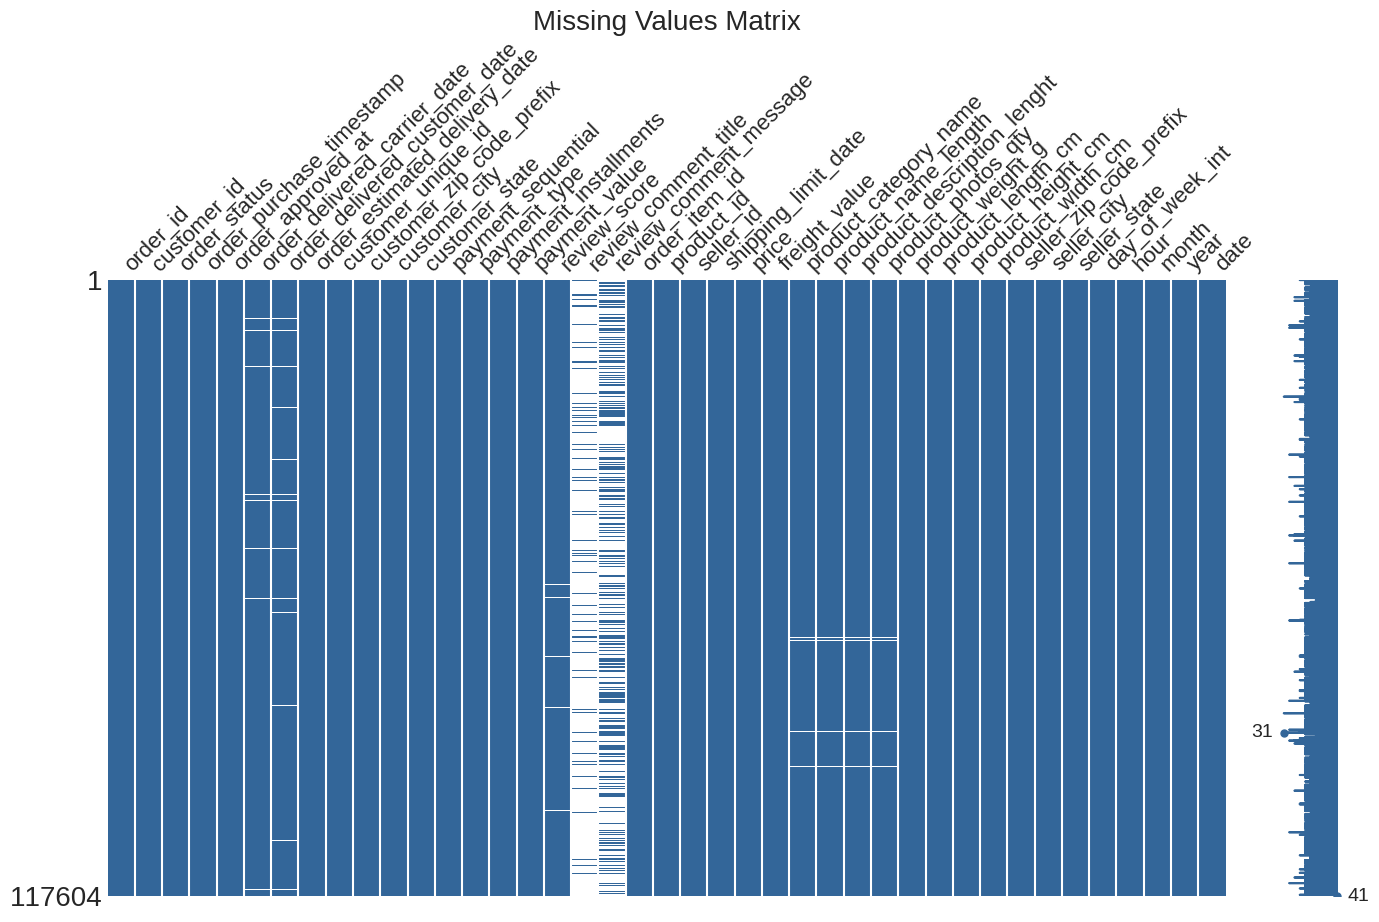

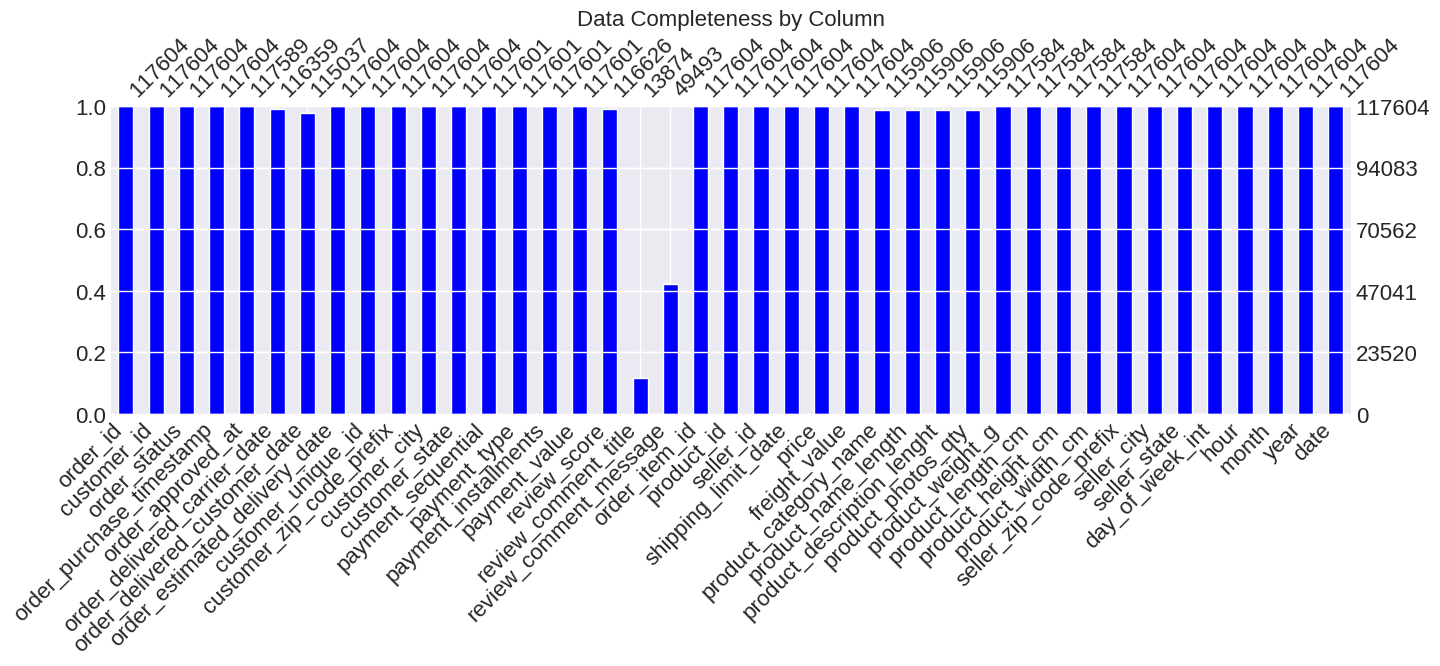

In [26]:
import missingno as msno
import matplotlib.pyplot as plt

# Plot a matrix to visualize the distribution and pattern of missing values
msno.matrix(df, figsize=(16, 8), color=(0.2, 0.4, 0.6))
plt.title('Missing Values Matrix', fontsize=20)
plt.show()

# Plot a bar chart to show the count of non-null (complete) data in each column
msno.bar(df, figsize=(16, 4), color='blue')
plt.title('Data Completeness by Column', fontsize=16)
plt.show()

--- Missing Values Analysis ---
                               Missing Count  Percentage (%)
review_comment_title                  103730           88.20
review_comment_message                 68111           57.92
order_delivered_customer_date           2567            2.18
product_description_lenght              1698            1.44
product_photos_qty                      1698            1.44
product_category_name                   1698            1.44
product_name_length                     1698            1.44
order_delivered_carrier_date            1245            1.06
review_score                             978            0.83
product_weight_g                          20            0.02


<Figure size 1000x600 with 0 Axes>

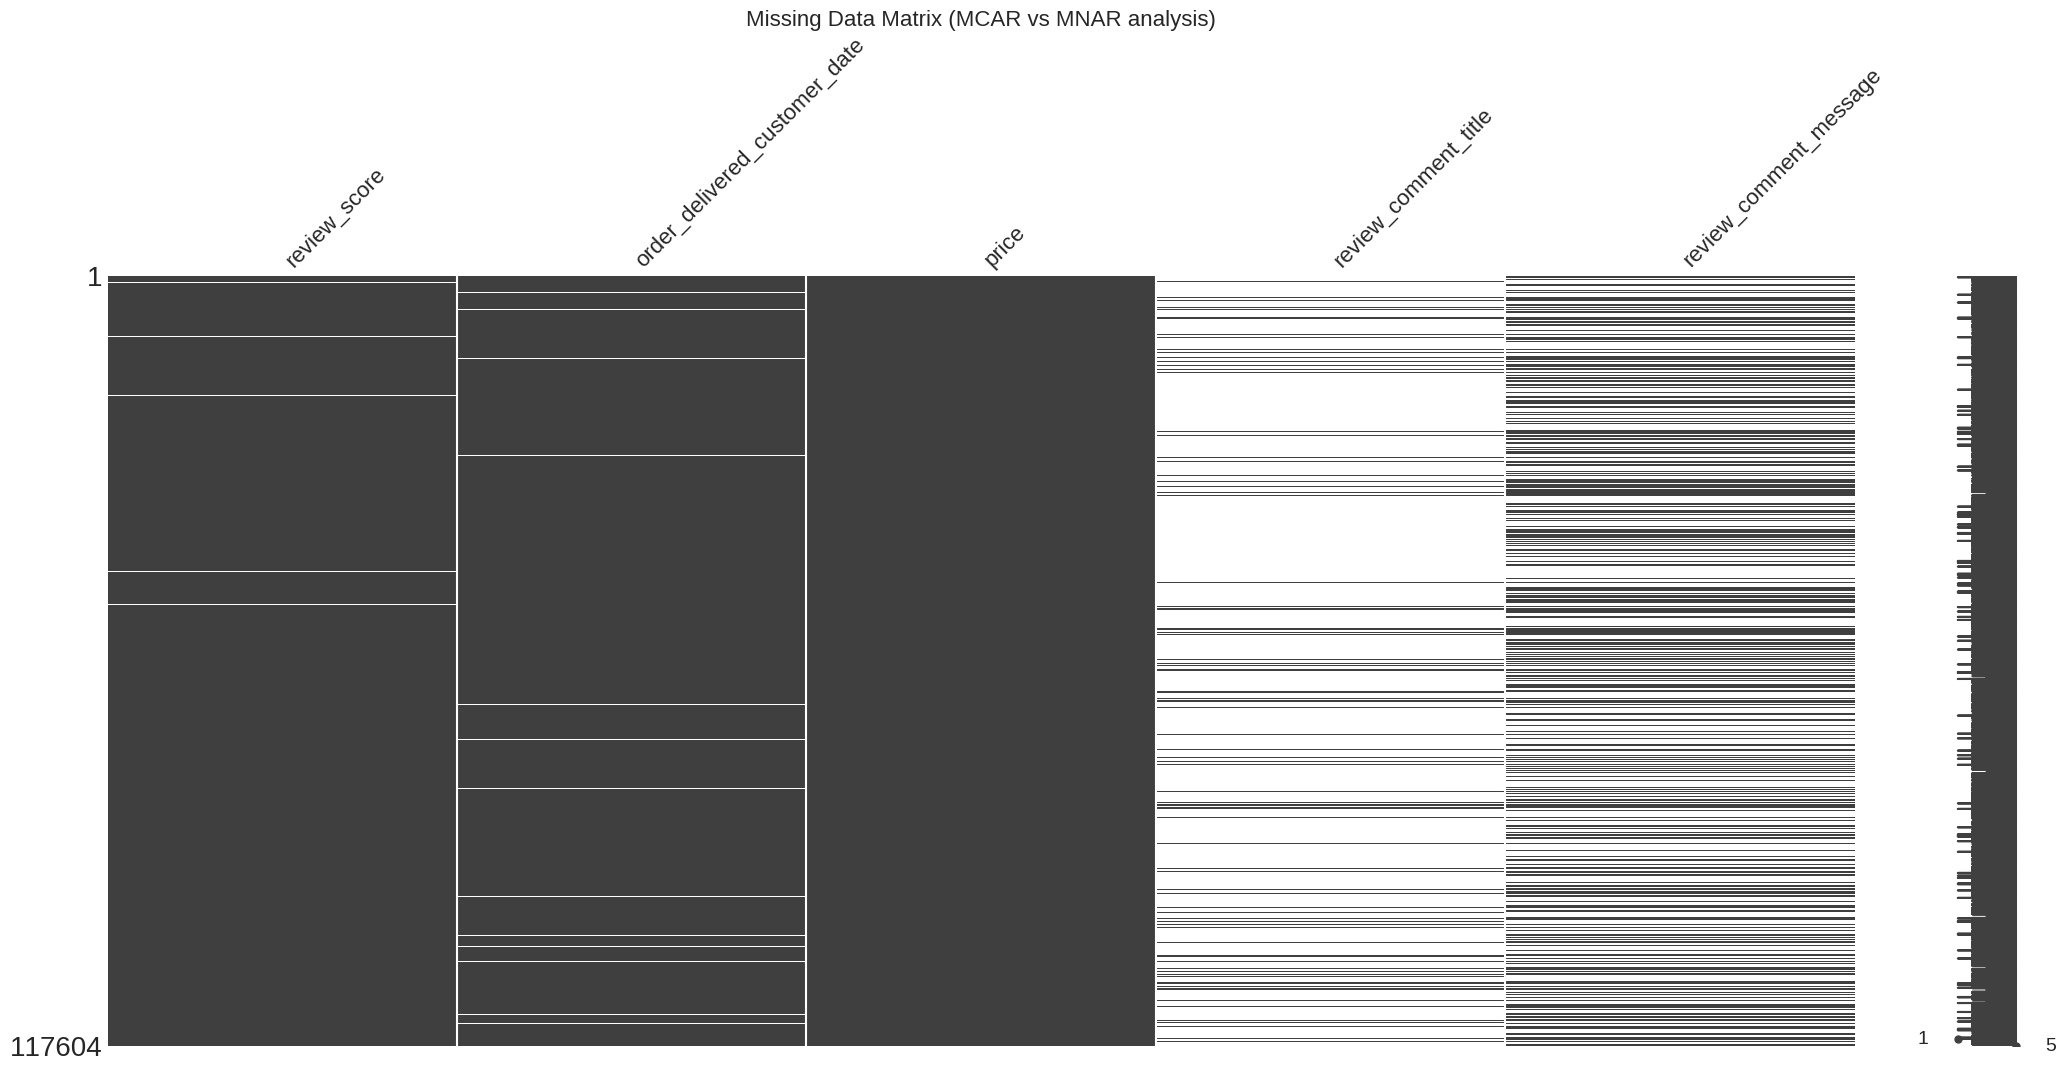

In [27]:
print("--- Missing Values Analysis ---")
missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_stats, 'Percentage (%)': missing_percent})
missing_df = missing_df[missing_df['Percentage (%)'] > 0].sort_values(by='Percentage (%)', ascending=False)
print(missing_df.head(10))

# Visualizing Missingness Mechanism
plt.figure(figsize=(10, 6))

# Dynamically select columns for msno.matrix to avoid KeyError
cols_to_visualize = ['review_score', 'order_delivered_customer_date', 'price']
if 'review_comment_title' in df.columns:
    cols_to_visualize.append('review_comment_title')
if 'review_comment_message' in df.columns:
    cols_to_visualize.append('review_comment_message')

msno.matrix(df[cols_to_visualize])
plt.title("Missing Data Matrix (MCAR vs MNAR analysis)", fontsize=16)
plt.show()

Missingness (review_comment_message & title): You will notice these are missing roughly 57% and 88% of the time. This is likely MNAR (Missing Not At Random). Customers typically only write text reviews if their experience was remarkably good (5 stars) or remarkably bad (1 star).


Missingness (delivery_time_days): Missing around 2.8%. These likely correlate with canceled or unavailable orders

In [28]:
print("\n--- Descriptive Statistics, Skewness, & Kurtosis ---")

# Ensure timestamp columns are in datetime format before calculation
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Calculate delivery_time_days
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

num_cols = ['price', 'freight_value', 'delivery_time_days', 'review_score']
# Drop NAs just for the shape calculation to avoid calculation errors
clean_num_df = df[num_cols].dropna()

shape_df = pd.DataFrame({
    'Skewness': clean_num_df.skew(),
    'Kurtosis': clean_num_df.kurt()
})
print(shape_df)


--- Descriptive Statistics, Skewness, & Kurtosis ---
                    Skewness  Kurtosis
price                   7.74    111.70
freight_value           5.58     58.88
delivery_time_days      3.81     39.48
review_score           -1.35      0.48


Skewness: price and freight_value will show exceptionally high positive skewness (Skew > 5) and extreme Kurtosis (> 50). This proves the presence of heavily right-tailed data (a few ultra-expensive items).

#Outlier detection

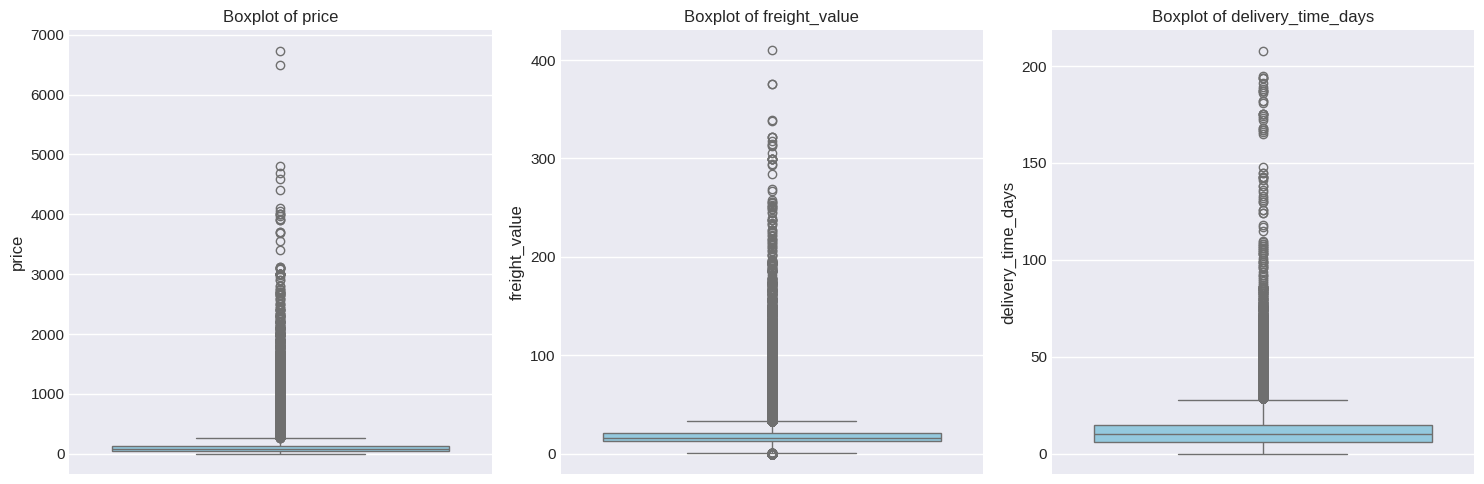

price -> Upper Bound (IQR): 272.65 | Outliers detected: 8536 (7.48%)
freight_value -> Upper Bound (IQR): 33.31 | Outliers detected: 11731 (10.27%)
delivery_time_days -> Upper Bound (IQR): 28.50 | Outliers detected: 5636 (4.94%)


In [29]:

# Plotting Boxplots for numerical variables
plt.figure(figsize=(15, 5))
for i, col in enumerate(['price', 'freight_value', 'delivery_time_days']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=clean_num_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Calculating exact Outlier Boundaries using the IQR method
for col in ['price', 'freight_value', 'delivery_time_days']:
    Q1 = clean_num_df[col].quantile(0.25)
    Q3 = clean_num_df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = len(clean_num_df[clean_num_df[col] > upper_bound])
    print(f"{col} -> Upper Bound (IQR): {upper_bound:.2f} | Outliers detected: {outliers_count} ({(outliers_count/len(clean_num_df))*100:.2f}%)")

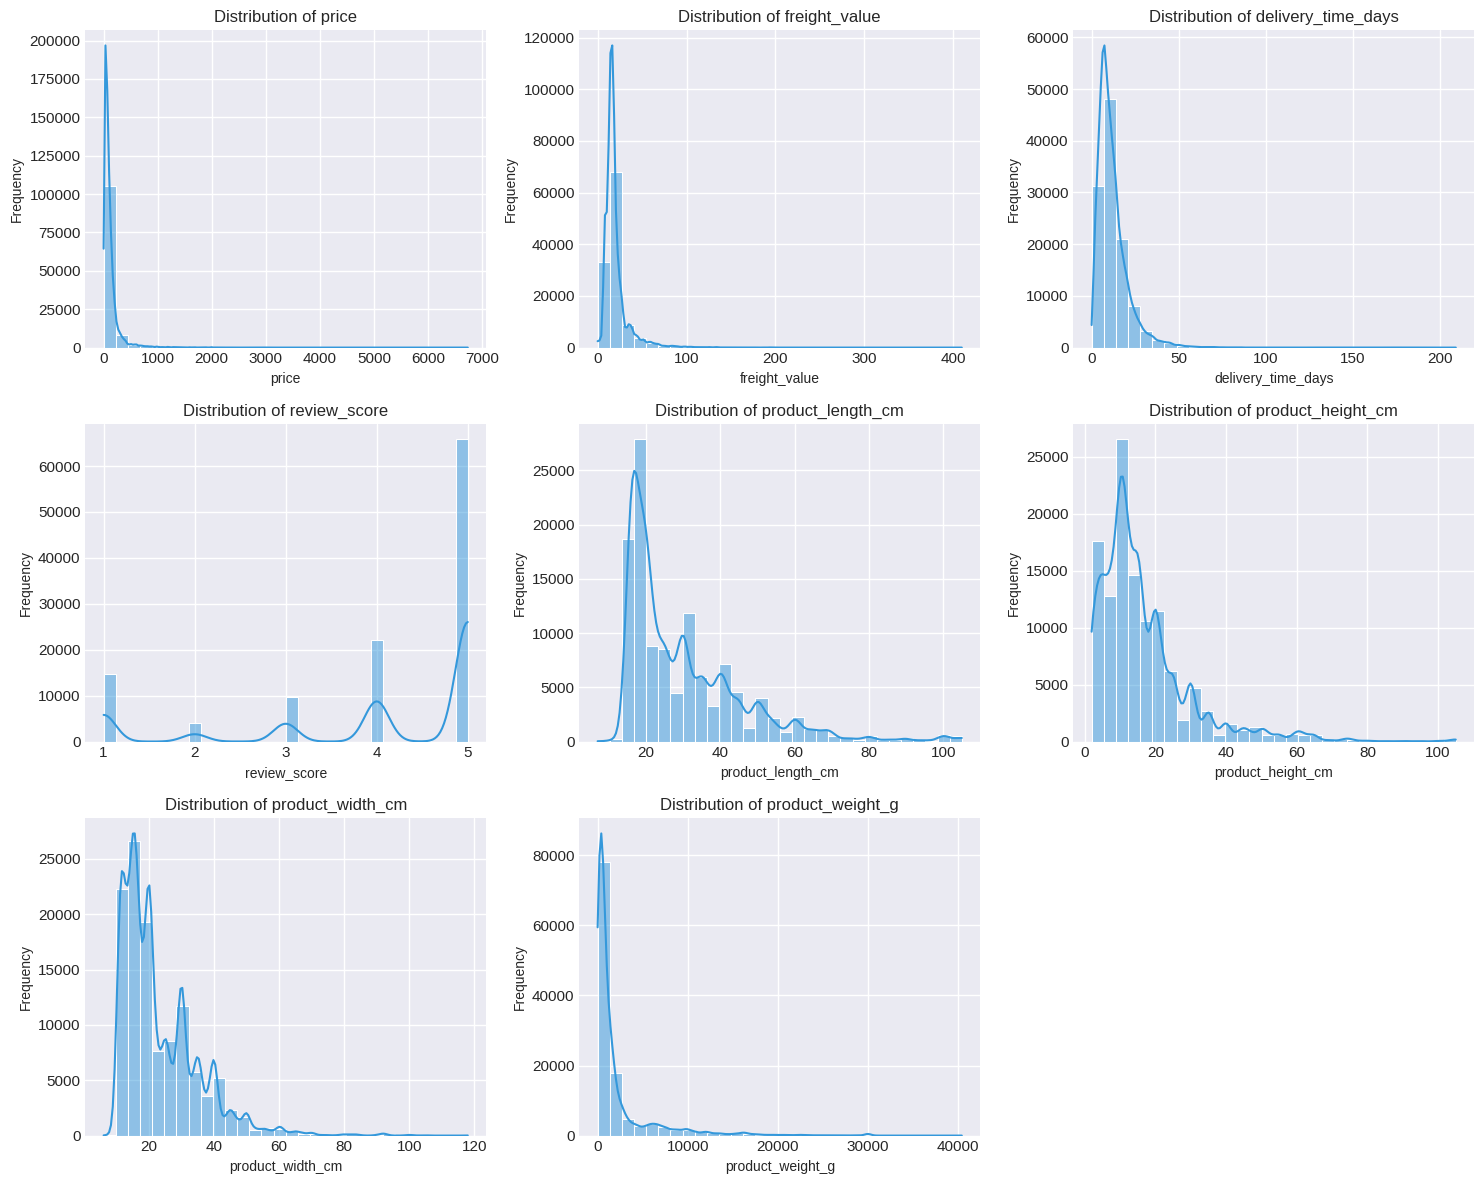

In [30]:
numerical_cols_to_plot = [
    'price', 'freight_value', 'delivery_time_days', 'review_score',
    'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_weight_g'
]

# Calculate the number of rows and columns for the subplot grid
num_plots = len(numerical_cols_to_plot)
num_cols_per_row = 3 # You can adjust this as needed
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row # Ceiling division

plt.figure(figsize=(num_cols_per_row * 5, num_rows * 4))

for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

#Further explore

In [31]:
# Merge df with df_category to get product_category_name_english
df = df.merge(df_category, on='product_category_name', how='left')

# Count the occurrences of each product category
category_counts = df['product_category_name_english'].value_counts()

# Set a threshold to decide which categories to keep
threshold = 3000
common_categories = category_counts[category_counts >= threshold].index

# Create a new column for simplified categories
df['simplified_category'] = df['product_category_name_english'].where(df['product_category_name_english'].isin(common_categories), 'Other')

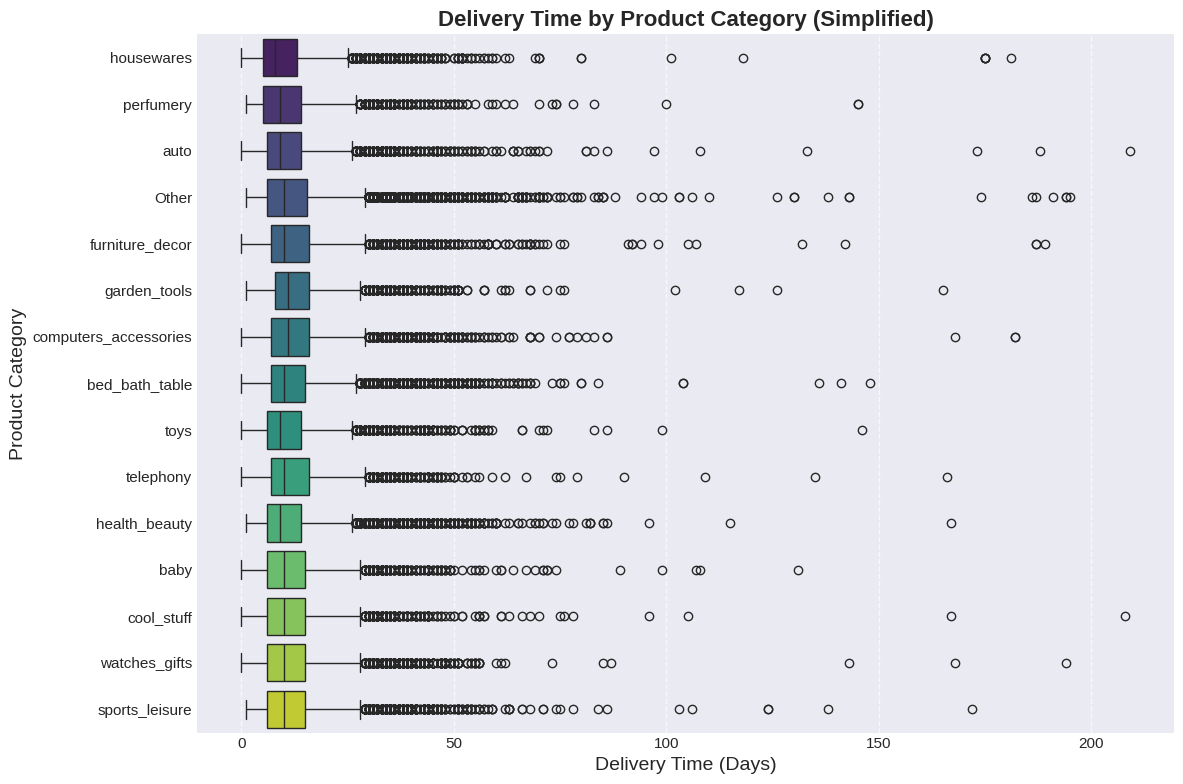

In [32]:
num_categories = df['simplified_category'].nunique()
colors = sns.color_palette('viridis', n_colors=num_categories)

plt.figure(figsize=(12, 8))

# Horizontal box plot for delivery time by simplified product category
sns.boxplot(x='delivery_time_days', y='simplified_category', data=df, palette=colors)

# Overlay swarm plot to show individual points
#sns.swarmplot(x='delivery_time_days', y='simplified_category', data=df, color='k', alpha=0.6, size=3)

# Adding titles and labels
plt.title('Delivery Time by Product Category (Simplified)', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Time (Days)', fontsize=14)
plt.ylabel('Product Category', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [33]:
# 2. Group by Category and Calculate Median & Mean
delivery_stats = df.groupby('product_category_name_english')['delivery_time_days'].agg(
    Median_Delivery_Days='median',
    Mean_Delivery_Days='mean'
)

# 3. Sort the results by Median delivery time (Slowest to Fastest)
delivery_stats_sorted = delivery_stats.sort_values(by='Median_Delivery_Days', ascending=False)

# 4. Display the top 15 categories (Matching our boxplot)
print("--- Mean and Median Delivery Time (in Days) by Category ---")
print(delivery_stats_sorted.head(15))

--- Mean and Median Delivery Time (in Days) by Category ---
                               Median_Delivery_Days  Mean_Delivery_Days
product_category_name_english                                          
office_furniture                              19.00               20.50
security_and_services                         15.00               15.00
christmas_supplies                            13.00               15.28
fashion_shoes                                 13.00               14.78
dvds_blu_ray                                  12.00               12.51
fashion_male_clothing                         11.00               12.72
agro_industry_and_commerce                    11.00               11.51
tablets_printing_image                        11.00               12.36
home_appliances_2                             11.00               13.21
home_confort                                  11.00               12.96
home_construction                             11.00               12.58
gard

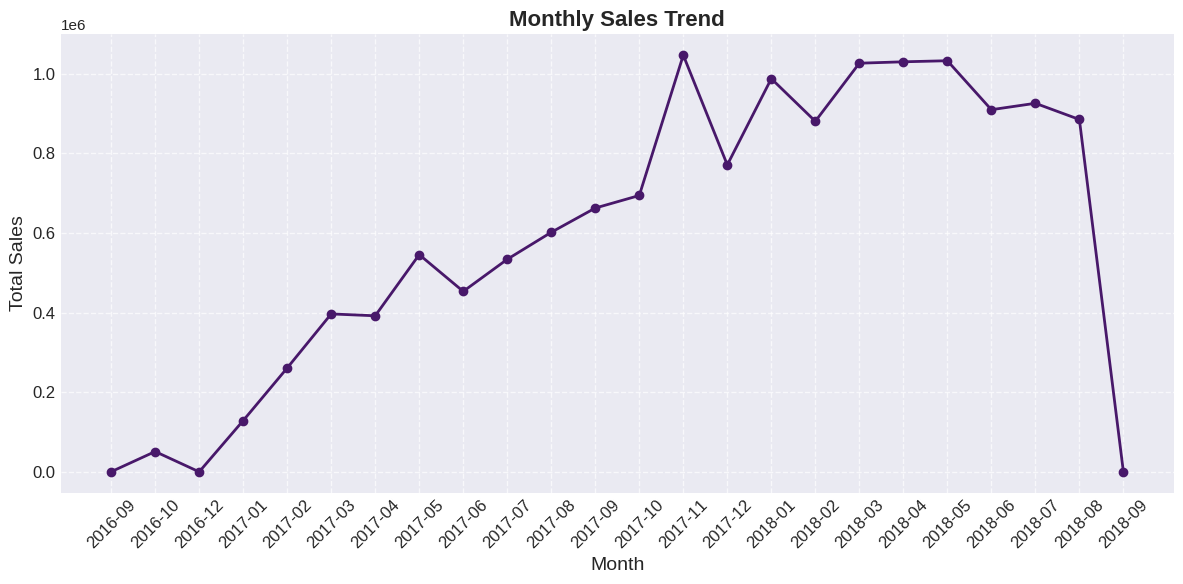

In [34]:
monthly_sales = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({'price': 'sum'})

# Set the figure size for better visibility
plt.figure(figsize=(12, 6))

# Plot the data with custom colors
plt.plot(monthly_sales.index.astype(str), monthly_sales['price'],
         marker='o', linestyle='-', color=colors[0], linewidth=2)

# Adding titles and labels
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)

# Customize the ticks
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

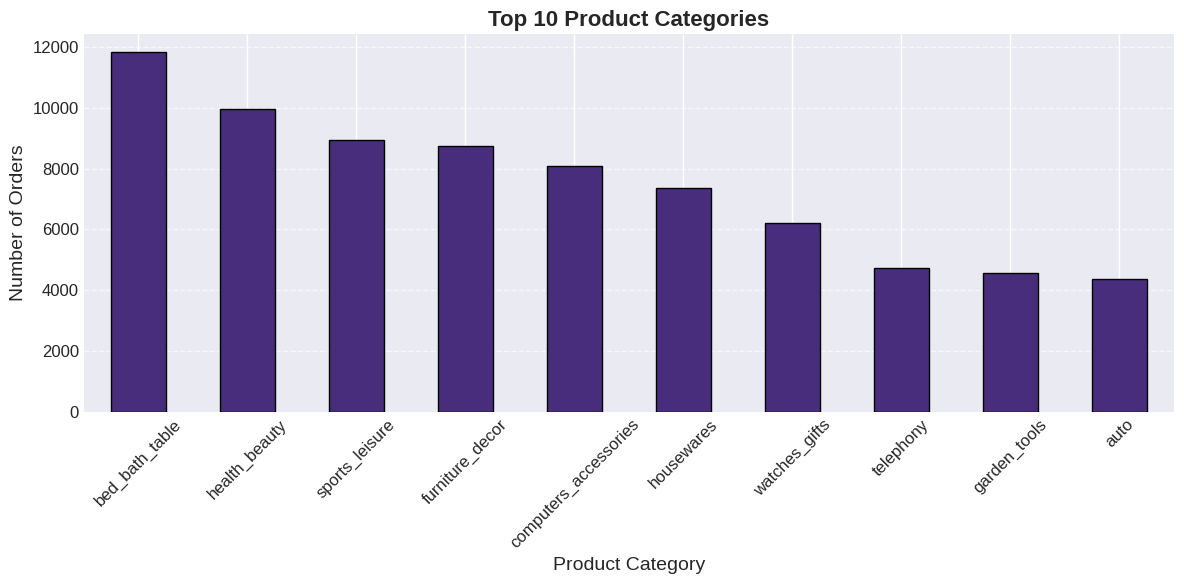

In [35]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Example: Orders by product category
top_categories = df['product_category_name_english'].value_counts().head(10)
top_categories.plot(kind='bar', color=colors[1], edgecolor='black')

# Adding titles and labels
plt.title('Top 10 Product Categories', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Number of Orders', fontsize=14)

# Customize ticks
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

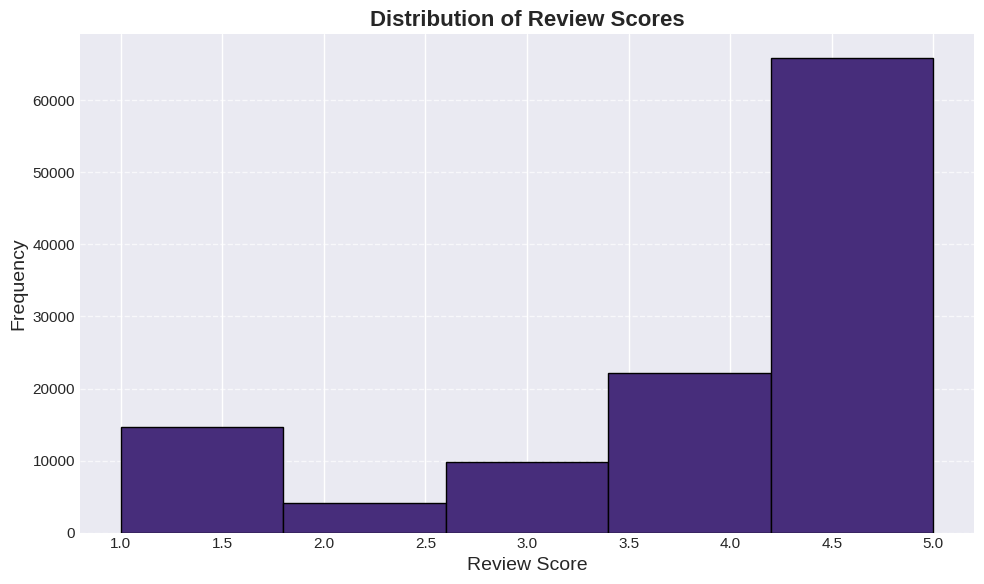

In [36]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Example: Distribution of review scores
df['review_score'].hist(bins=5, color=colors[1], edgecolor='black')

# Adding titles and labels
plt.title('Distribution of Review Scores', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

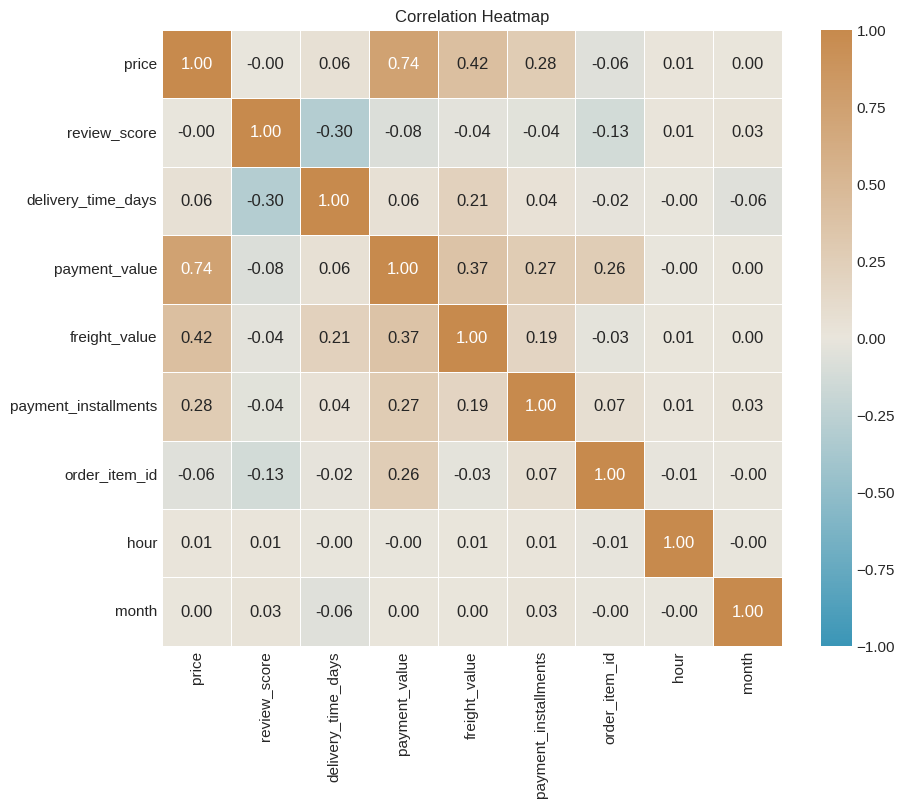

In [37]:
from matplotlib.colors import LinearSegmentedColormap

# Select relevant features for correlation analysis
correlation_features = df[['price', 'review_score', 'delivery_time_days',
                            'payment_value', 'freight_value',
                            'payment_installments', 'order_item_id',
                            'hour', 'month']]

# Calculate the correlation matrix
correlation = correlation_features.corr()

# Define the custom colormap
custom_colors = ['#3B96B7', '#E9E5DC', '#C78A4D']
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap=custom_cmap, vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

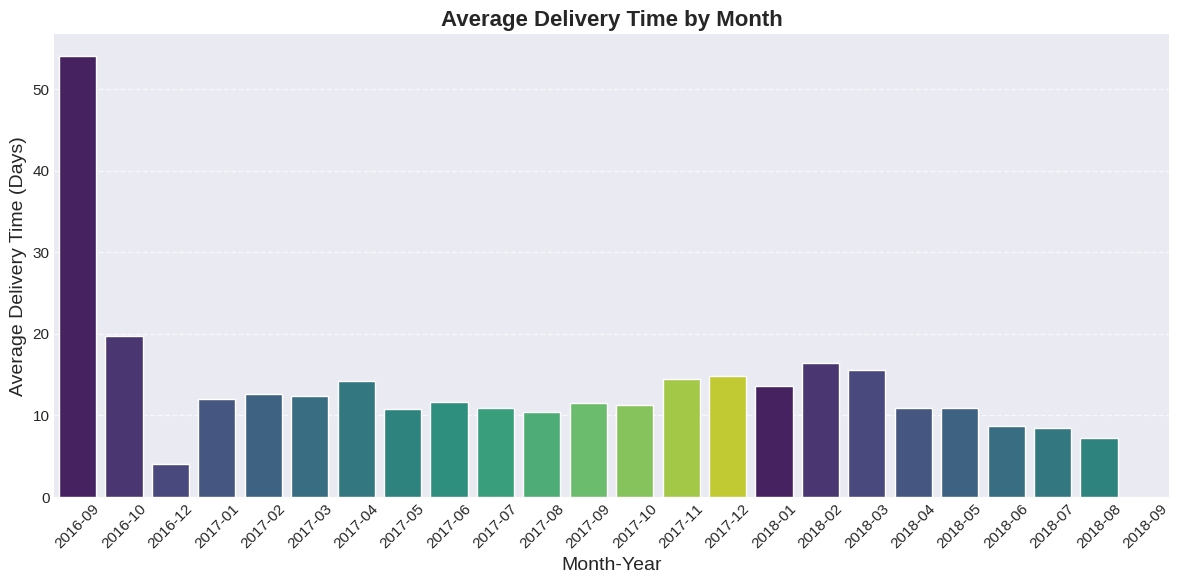

In [38]:
# Create a new DataFrame for the monthly average delivery time
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_delivery_time = df.groupby('month_year')['delivery_time_days'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='month_year', y='delivery_time_days', data=monthly_delivery_time, palette=colors)
plt.title('Average Delivery Time by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Average Delivery Time (Days)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**Data preprocessing**

#Handling Missing variable

In [39]:
print("\n--- Missing Values Analysis ---")
missing_stats = df.isnull().sum()
missing_percent = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_stats, 'Percentage (%)': missing_percent})
missing_df = missing_df[missing_df['Percentage (%)'] > 0].sort_values(by='Percentage (%)', ascending=False)
print(missing_df)


--- Missing Values Analysis ---
                               Missing Count  Percentage (%)
review_comment_title                  103730           88.20
review_comment_message                 68111           57.92
order_delivered_customer_date           2567            2.18
delivery_time_days                      2567            2.18
product_category_name_english           1723            1.47
product_photos_qty                      1698            1.44
product_name_length                     1698            1.44
product_description_lenght              1698            1.44
product_category_name                   1698            1.44
order_delivered_carrier_date            1245            1.06
review_score                             978            0.83
product_length_cm                         20            0.02
product_height_cm                         20            0.02
product_weight_g                          20            0.02
product_width_cm                          20        

In [40]:
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')
df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())
df['product_length_cm'] = df['product_length_cm'].fillna(df['product_length_cm'].median())
df['product_height_cm'] = df['product_height_cm'].fillna(df['product_height_cm'].median())
df['product_width_cm'] = df['product_width_cm'].fillna(df['product_width_cm'].median())

In [41]:
# 1. Handling Missing Text Data (Reviews)
df['review_comment_title'] = df['review_comment_title'].fillna('No Title')
df['review_comment_message'] = df['review_comment_message'].fillna('No Comment')

In [42]:
# 2. Handling Missing Categorical Data (Product Category)
df['product_category_name'] = df['product_category_name'].fillna('Unknown')

In [43]:
# 3. Handling Missing Numerical Data (Product Dimensions & Weight)
# Using Median is safer than Mean to avoid outliers
numeric_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [44]:

# 4. Handling Logistics Dates for ALL orders (including canceled)
# We keep the entire dataset `df`. We just ensure all date columns are properly
# formatted as Datetime objects. Pandas will automatically handle missing dates as 'NaT' (Not a Time).

date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'shipping_limit_date']

for col in date_cols:
    # errors='coerce' ensures any weird string values become NaT instead of crashing
    df[col] = pd.to_datetime(df[col], errors='coerce')

# BI Feature Engineering Example:
# Let's calculate the actual delivery time in days.
# For canceled orders, this math will safely and automatically result in 'NaN'.
df['actual_delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

print("Dataset Shape including canceled orders:", df.shape)
print("Count of orders by status:\n", df['order_status'].value_counts())

Dataset Shape including canceled orders: (117604, 46)
Count of orders by status:
 order_status
delivered      115038
shipped          1244
canceled          566
processing        375
invoiced          371
unavailable         7
approved            3
Name: count, dtype: int64


In [45]:
# 5. Check remaining missing values in the FULL dataset
print("Remaining missing values across all orders (including canceled):\n")
missing_check = df.isnull().sum()

# Filter to show only columns that still have missing values
remaining_missing = missing_check[missing_check > 0]
print(remaining_missing)

# BI Sanity Check: Calculate the percentage to understand the scale
print("\n--- Percentage of Missing Values ---")
print((remaining_missing / len(df)) * 100)

Remaining missing values across all orders (including canceled):

order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
review_score                      978
product_name_length              1698
product_description_lenght       1698
product_photos_qty               1698
delivery_time_days               2567
actual_delivery_days             2567
dtype: int64

--- Percentage of Missing Values ---
order_approved_at               0.01
order_delivered_carrier_date    1.06
order_delivered_customer_date   2.18
payment_sequential              0.00
payment_type                    0.00
payment_installments            0.00
payment_value                   0.00
review_score                    0.83
product_name_length             1.44
product_description_lenght      1.44
product_photos_qty 

In [46]:
# We create a new feature: 1 if they commented, 0 if they didn't.
df['is_vocal_customer'] = df['review_comment_message'].notnull().astype(int)

The "Silence" is a Feature: In our future ML model, is_vocal_customer = 0 will likely correlate strongly with a 5-star rating, because happy people often don't feel the need to complain in writing

In [47]:
mask = (df_orders['order_approved_at'].isnull()) & (df_orders['order_status']=='canceled')
df_orders[mask].head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00


In [48]:
df_orders[df_orders["order_approved_at"].isnull()]["order_status"].value_counts()

,count
order_status,
canceled,141
delivered,14
created,5


In [49]:
# Identify ONLY the delivered orders that are missing an approval date
delivered_missing_approval = (df['order_approved_at'].isnull()) & (df['order_status'] == 'delivered')

# Apply my logic (assume approval = purchase time) ONLY to those 14 rows
df.loc[delivered_missing_approval, 'order_approved_at'] = df.loc[delivered_missing_approval, 'order_purchase_timestamp']

# Note: The 141 'canceled' and 5 'created' orders will logically remain as NaT (Not a Time)
# because they were likely never approved in the real world.

In [50]:
df_orders[(df_orders["order_delivered_carrier_date"].isnull()) & (df_orders["order_status"] == "delivered")]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


In [51]:

# 1. Create a Delivery Status Flag (Critical for BI Dashboards)
df['is_delivered'] = np.where(df['order_status'] == 'delivered', 1, 0)

# 2. Impute missing 'customer delivery date' for delivered orders using the estimated date
mask_customer = (df['order_status'] == 'delivered') & (df['order_delivered_customer_date'].isnull())
df.loc[mask_customer, 'order_delivered_customer_date'] = df.loc[mask_customer, 'order_estimated_delivery_date']

# 3. Impute missing 'carrier delivery date' (the 2 rows you found earlier)
# If it was delivered, the carrier must have had it. We use the approval date as the safest proxy.
mask_carrier = (df['order_status'] == 'delivered') & (df['order_delivered_carrier_date'].isnull())
df.loc[mask_carrier, 'order_delivered_carrier_date'] = df.loc[mask_carrier, 'order_approved_at']

In [52]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,1243
order_delivered_customer_date,2559
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


#Handling outlier

In [53]:

# Hard Trimming for impossible values (Moved UP)
# We must explicitly keep NaNs so we don't delete canceled orders!
df = df[(df['delivery_time_days'] >= 0) | (df['delivery_time_days'].isnull())]

# Strategy B: Winsorization for Logistics
# CRITICAL FIX: Use Pandas native .clip() instead of scipy's winsorize
# because scipy will crash or create a 'Masked Array' when it encounters our NaNs.
upper_limit = df['delivery_time_days'].quantile(0.95)
df['delivery_time_winsorized'] = df['delivery_time_days'].clip(upper=upper_limit)

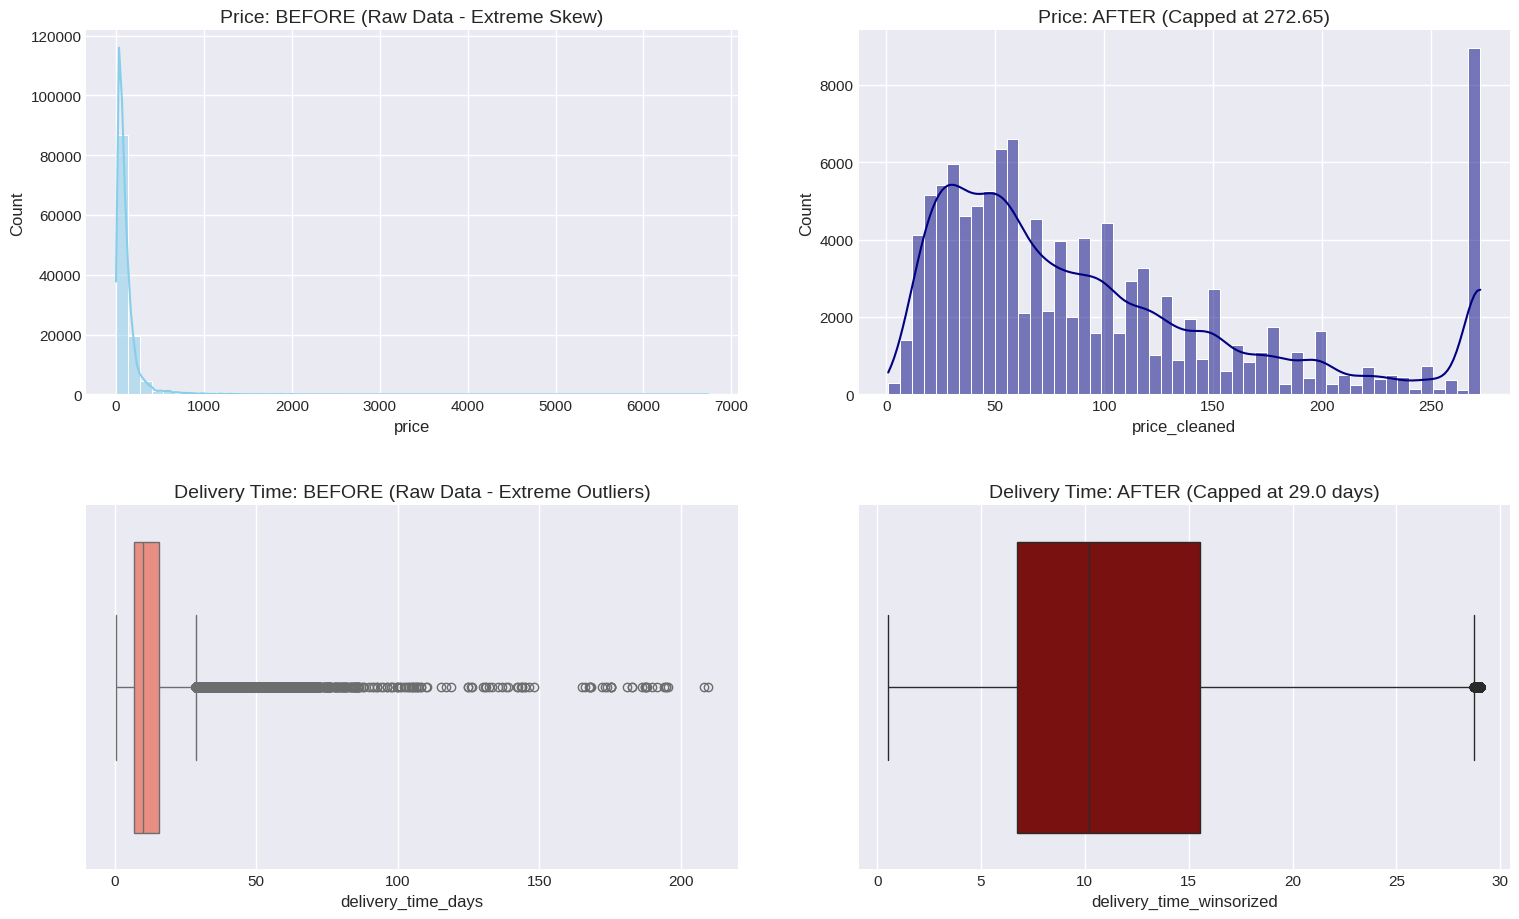

In [54]:

# 1. PREPARE DATA
# Calculate Delivery Time safely
df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (24*3600)

# Create a copy for plotting and drop NAs for these specific visual columns
plot_df = df.dropna(subset=['delivery_time_days', 'price']).copy()

# 2. APPLY TRANSFORMATIONS (No Log, No Scipy)

# Strategy A: Price Capping (Using IQR method instead of Log)
Q1 = plot_df['price'].quantile(0.25)
Q3 = plot_df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound_price = Q3 + 1.5 * IQR
plot_df['price_cleaned'] = plot_df['price'].clip(upper=upper_bound_price)

# Strategy B: Delivery Time Capping (95th percentile) using Pandas .clip()
upper_limit_delivery = plot_df['delivery_time_days'].quantile(0.95)
plot_df['delivery_time_winsorized'] = plot_df['delivery_time_days'].clip(upper=upper_limit_delivery)

# 3. GENERATE COMPARISON GRAPHS
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- ROW 1: PRICE (IQR Capping instead of Log) ---
sns.histplot(plot_df['price'], bins=50, ax=axes[0,0], color='skyblue', kde=True)
axes[0,0].set_title('Price: BEFORE (Raw Data - Extreme Skew)', fontsize=14)

sns.histplot(plot_df['price_cleaned'], bins=50, ax=axes[0,1], color='navy', kde=True)
axes[0,1].set_title(f'Price: AFTER (Capped at {upper_bound_price:.2f})', fontsize=14)

# --- ROW 2: DELIVERY TIME (Winsorization via .clip) ---
sns.boxplot(x=plot_df['delivery_time_days'], ax=axes[1,0], color='salmon')
axes[1,0].set_title('Delivery Time: BEFORE (Raw Data - Extreme Outliers)', fontsize=14)

sns.boxplot(x=plot_df['delivery_time_winsorized'], ax=axes[1,1], color='darkred')
axes[1,1].set_title(f'Delivery Time: AFTER (Capped at {upper_limit_delivery:.1f} days)', fontsize=14)

plt.tight_layout(pad=3.0)
plt.show()

**Standardize product and category name**

In [55]:
# 1. Standardize product and category name
df['product_category_name'] = df['product_category_name'].str.lower().str.strip().str.replace(' ', '_')

# If you need to apply this to product_name later, it is just one line:
# df['product_name'] = df['product_name'].str.lower().str.strip().str.replace(' ', '_')

**Parse and split date into Year/Month/Day**

In [56]:
# =====================================================================
# 2. Parse and split date into Year/Month/Day
# =====================================================================

# First: Convert the timestamp column to datetime objects
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Second: Extract Year, Month, and Day into separate new columns
df['Year'] = df['order_purchase_timestamp'].dt.year
df['Month'] = df['order_purchase_timestamp'].dt.month
df['Day'] = df['order_purchase_timestamp'].dt.day

# (Optional) Extract Hour and Day of the Week for deeper time-series analysis
df['Hour'] = df['order_purchase_timestamp'].dt.hour
df['Day_of_Week'] = df['order_purchase_timestamp'].dt.day_name()

# Display the first few rows to verify the changes
# print(df[['product_category_name', 'order_purchase_timestamp', 'Year', 'Month', 'Day']].head())

#Future engrening

In [57]:
# Calculate delivery time in days
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [58]:
# Extract the Year (e.g., 2017, 2018)
df['purchase_year'] = df['order_purchase_timestamp'].dt.year

# Extract the Month as a number (1 to 12)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek



In [59]:
df['is_weekend'] = np.where(df['purchase_day_of_week'] >= 5, 1, 0)

In [60]:
# Ensure estimated date is datetime
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')

In [61]:
# Delay in days (Actual Delivery - Estimated Delivery)
# If > 0, it means the order was LATE. If < 0, it arrived EARLY.
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.total_seconds() / (24*3600)

In [62]:
# Flag for late deliveries
df['is_late'] = np.where(df['delivery_delay_days'] > 0, 1, 0)

In [63]:

# Freight Ratio (Prevent division by zero by adding a tiny number)
df['freight_ratio'] = df['freight_value'] / (df['price'] + 0.001)

In [64]:
# Product Volume
df['product_volume_cm3'] = df['product_length_cm'] * df['product_width_cm'] * df['product_height_cm']

In [65]:
# --- 4. CUSTOMER EXPERIENCE ---
# Categorize reviews: 1-2 = Detractor, 3 = Passive, 4-5 = Promoter
conditions = [
    (df['review_score'] >= 4),
    (df['review_score'] == 3),
    (df['review_score'] <= 2)
]
choices = ['satisfied', 'natural', 'not_satisfied']
df['satisfaction_class'] = np.select(conditions, choices, default='Unknown')

print("Feature Engineering Complete. Current Dataset Shape:", df.shape)

Feature Engineering Complete. Current Dataset Shape: (117604, 64)



# **Phase 3: `(EDA) After Cleaning`.**

### **Goal: `Descriptive Analytics` & `Data Storytelling`**

---

## **3.1 Univariate Analysis** (**`Data Distributions`**)

* **Objective:** Understand the Distribution, Central Tendency, and Spread of **`Individual variables`**.

* **Business Focus:**

* What is the Distribution of **Product Prices**?

* What is the frequency of Different **Review Scores** (1 to 5 stars)?

* What is the Volume of **Orders Per Month**?

---

## **3.2 Bivariate Analysis (`Relationship Discovery`)**

* **Objective:** Explore the **`Relationship Between Two Variables`** to identify cause-and-effect patterns.

* **Business Focus:**

* How does **'Delivery Time'** Affect the **'Review Score'**?

* Is There a Relationship Between **'Freight Value'** (Shipping Cost) and **'Product Category'**?

* Sales trends over time **(Time vs. Revenue)**.

---
## **3.3 Multivariate Analysis & Correlation (`Feature Importance`)**

* **Objective:** Analyze **`Interactions Among Three or More variables simultaneously`** and Determine Statistical Correlations.

* **Business Focus:**

* **Correlation Heatmap:** Which Numerical Variables are Most Strongly Correlated with Customer Satisfaction or Revenue?

* **Feature Importance:** Identifying the most critical factors that lead to order cancellations or bad reviews.

---

## **3.1 Univariate Analysis** (**`Data Distributions`**)

### **1. `Continuous Numerical Variables`**

In [66]:
# ============================================================================
# First Checking Number of Columns and Data-types of It's.
# ============================================================================
print("Data Informations - (Columns)")
print("=" * 60, "...\n")

df.info()

print("...\n")
print("=" * 60)
# ============================================================================

Data Informations - (Columns)
============================================================ ...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117604 entries, 0 to 117603
Data columns (total 64 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117604 non-null  object        
 1   customer_id                    117604 non-null  object        
 2   order_status                   117604 non-null  object        
 3   order_purchase_timestamp       117604 non-null  datetime64[ns]
 4   order_approved_at              117604 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116361 non-null  datetime64[ns]
 6   order_delivered_customer_date  115045 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117604 non-null  datetime64[ns]
 8   customer_unique_id             117604 non-null  object        
 9   customer_zip_code_prefix       117604 no

In [67]:
# ============================================================================
# Ok...! We Have - (64 Columns).
#
# (6 - Date-Time).
# (20 - Float).
# (18 - Int).
# (18 - Object).
# (2 - period[M]).
# ============================================================================
#
# First Explore Numerical Columns.
#
# ============================================================================

def plot_numerical_distribution(dataframe, column_name, zoom_percentile=100):
    """
    Plots a Histogram (with KDE) and a Boxplot.
    Includes a 'zoom_percentile' argument to visually clip extreme outliers
    (e.g., set to 95 to focus on the core 95% of the data), making skewed
    business metrics (like price) much easier to read.
    """
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True,
                                          gridspec_kw={"height_ratios": (.15, .85)},
                                          figsize=(10, 6))

    # Calculate the upper limit dynamically based on the requested percentile
    upper_limit = np.percentile(dataframe[column_name].dropna(), zoom_percentile)


    # Filter data purely for visualization (does NOT drop outliers from original dataframe)
    viz_data = dataframe[dataframe[column_name] <= upper_limit]


    # Top plot: Boxplot for outliers and quartiles
    sns.boxplot(data=viz_data, x=column_name, ax=ax_box, color="lightblue")
    ax_box.set(xlabel='')

    # Bottom plot: Histogram + KDE for distribution shape
    sns.histplot(data=viz_data, x=column_name, ax=ax_hist, kde=True, bins=50, color="steelblue")

    plt.suptitle(f'Univariate Distribution: {column_name} (Zoomed to {zoom_percentile}th Percentile)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# This will show you the exact shape of the normalو ignoring the extreme giants!
# plot_numerical_distribution(df_clean, 'price', zoom_percentile=95)

# ============================================================================

... Analyzing the Distribution of (Product Prices)...

============================================================ ...



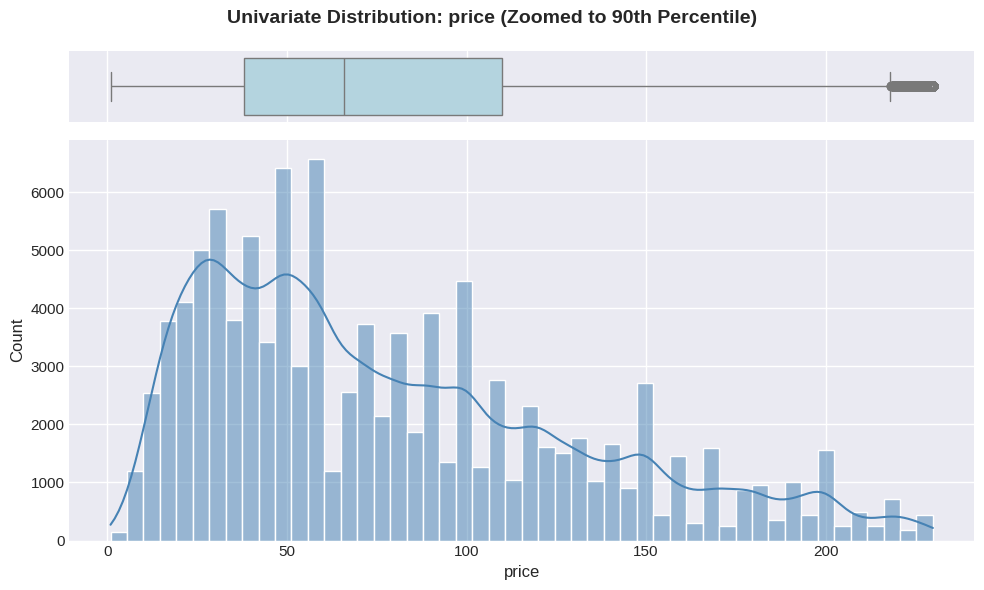

...



In [68]:
# ============================================================================
#  Step 2: Executing the Function on key Business Metrics
#
# 1. Analyzing the Distribution of (Product Prices).
#
# ============================================================================
print("... Analyzing the Distribution of (Product Prices)...\n")
print("=" * 60, "...\n")

plot_numerical_distribution(df, 'price', 90)

print("...\n")
print("=" * 60)
# ============================================================================

... Analyzing the Distribution of (Shipping Costs)...

============================================================ ...



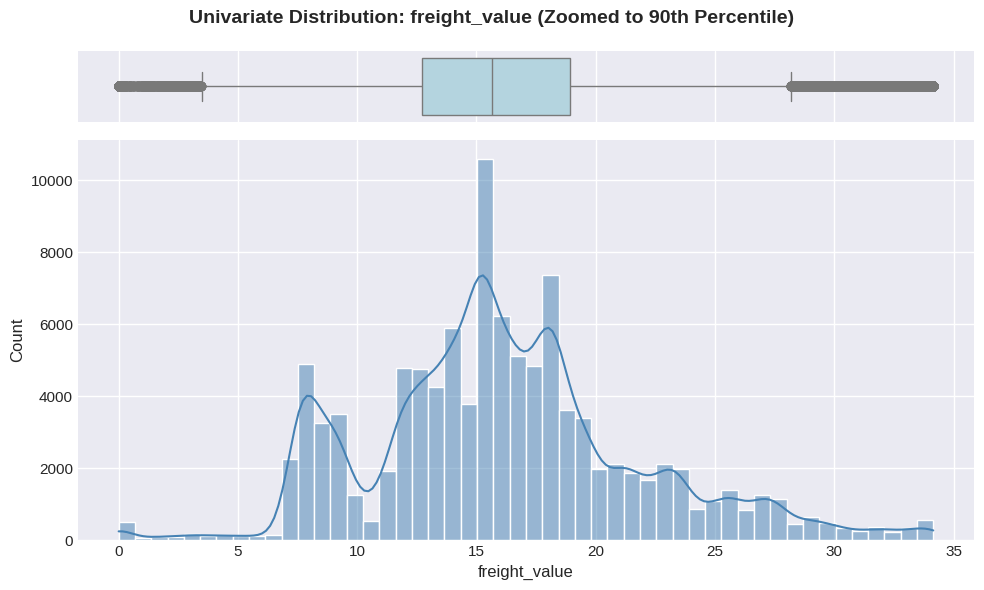

...



In [69]:
# ============================================================================
#
#  2. Analyzing the Distribution of (Shipping Costs).
#
# ============================================================================
print("... Analyzing the Distribution of (Shipping Costs)...\n")
print("=" * 60, "...\n")

plot_numerical_distribution(df, 'freight_value', 90)

print("...\n")
print("=" * 60)

# ============================================================================

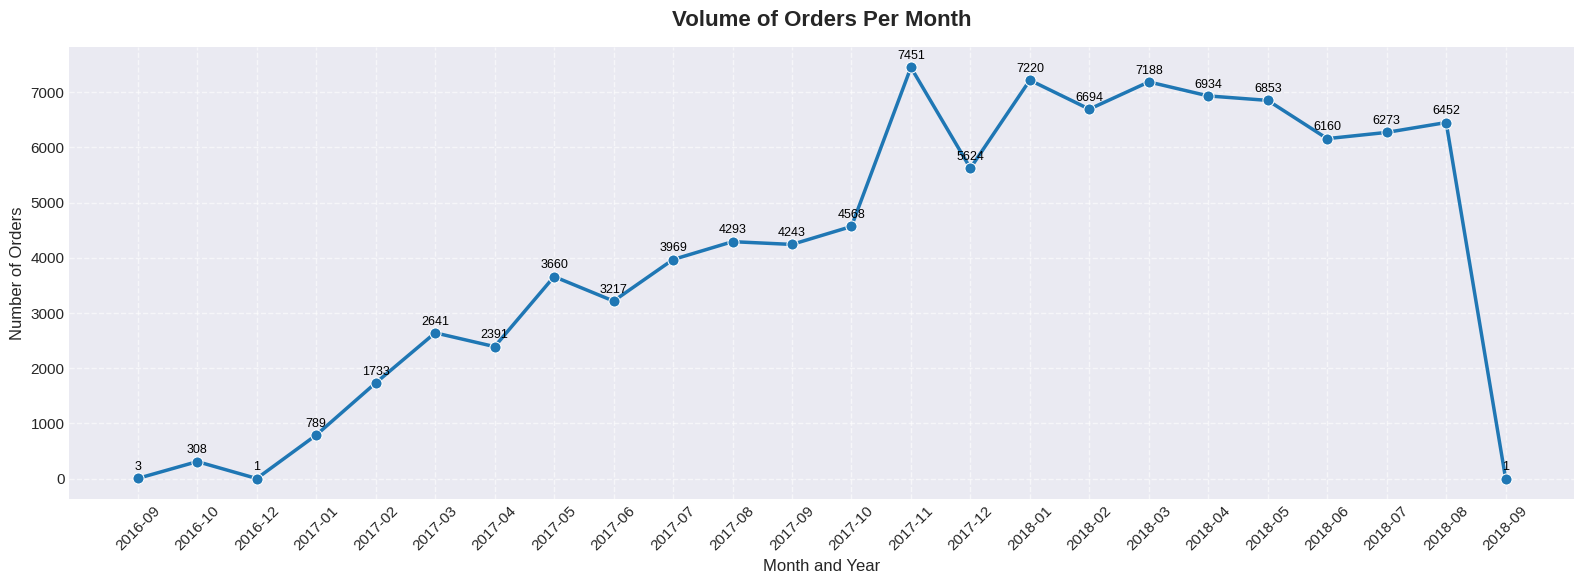

In [70]:
# ============================================================================
# Univariate Analysis: What is the Volume of Orders Per Month?
# ============================================================================

# 1. Ensure the purchase date column is in datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2. Extract Year and Month into a new column (e.g., '2017-08')
df['order_month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

# 3. Drop duplicated order_ids to count actual unique orders, not order items
unique_orders = df.drop_duplicates(subset=['order_id'])

# 4. Group by the new Year-Month column and count the orders
monthly_orders = unique_orders.groupby('order_month_year').size().reset_index(name='order_count')

# Convert the period to string so Seaborn can plot it easily
monthly_orders['order_month_year'] = monthly_orders['order_month_year'].astype(str)

# 5. Plotting the trend using a Line Plot
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=monthly_orders,
    x='order_month_year',
    y='order_count',
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    markersize=8
)

# Formatting the chart
plt.title('Volume of Orders Per Month', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month and Year', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Adding text labels on top of each marker to show the exact number of orders
for index, row in monthly_orders.iterrows():
    plt.text(row['order_month_year'], row['order_count'] + 150,
             str(row['order_count']), color='black', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## **3.2 Bivariate Analysis (`Relationship Discovery`)**

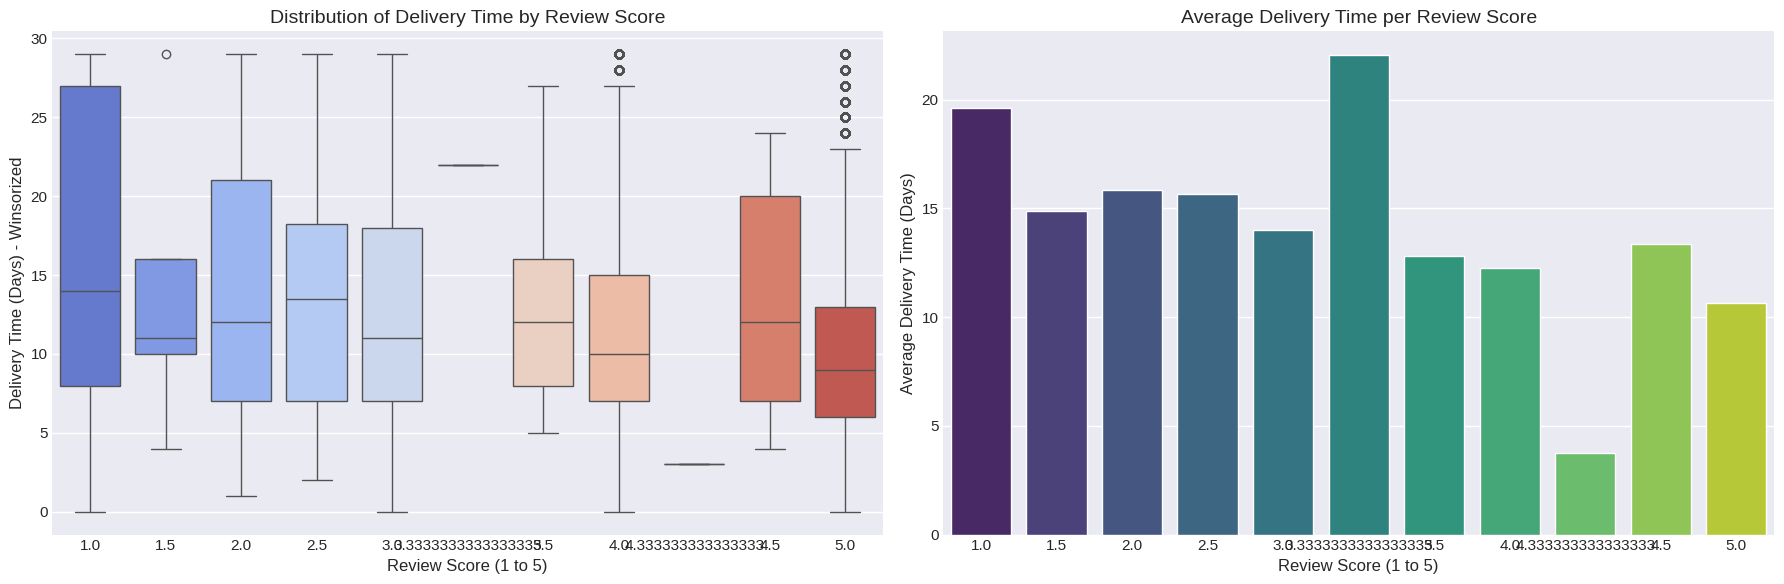

Correlation between Delivery Time and Review Score: -0.304


In [71]:
# ============================================================================
# Bivariate Analysis: How does 'Delivery Time' affect the 'Review Score'?
# ============================================================================

# Drop missing values to avoid plotting errors
plot_data = df.dropna(subset=['review_score', 'delivery_time_winsorized'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Boxplot: Distribution of delivery time across different review scores
sns.boxplot(
    data=plot_data,
    x='review_score',
    y='delivery_time_winsorized',
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title('Distribution of Delivery Time by Review Score', fontsize=14)
axes[0].set_xlabel('Review Score (1 to 5)', fontsize=12)
axes[0].set_ylabel('Delivery Time (Days) - Winsorized', fontsize=12)

# 2. Barplot: Average delivery time for each review score
sns.barplot(
    data=plot_data,
    x='review_score',
    y='delivery_time_days',
    errorbar=None,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Average Delivery Time per Review Score', fontsize=14)
axes[1].set_xlabel('Review Score (1 to 5)', fontsize=12)
axes[1].set_ylabel('Average Delivery Time (Days)', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================================
# Statistical Correlation
# ============================================================================

# Calculate Pearson correlation coefficient to measure the strength and direction
correlation = plot_data[['delivery_time_days', 'review_score']].corr().iloc[0, 1]
print(f"Correlation between Delivery Time and Review Score: {correlation:.3f}")

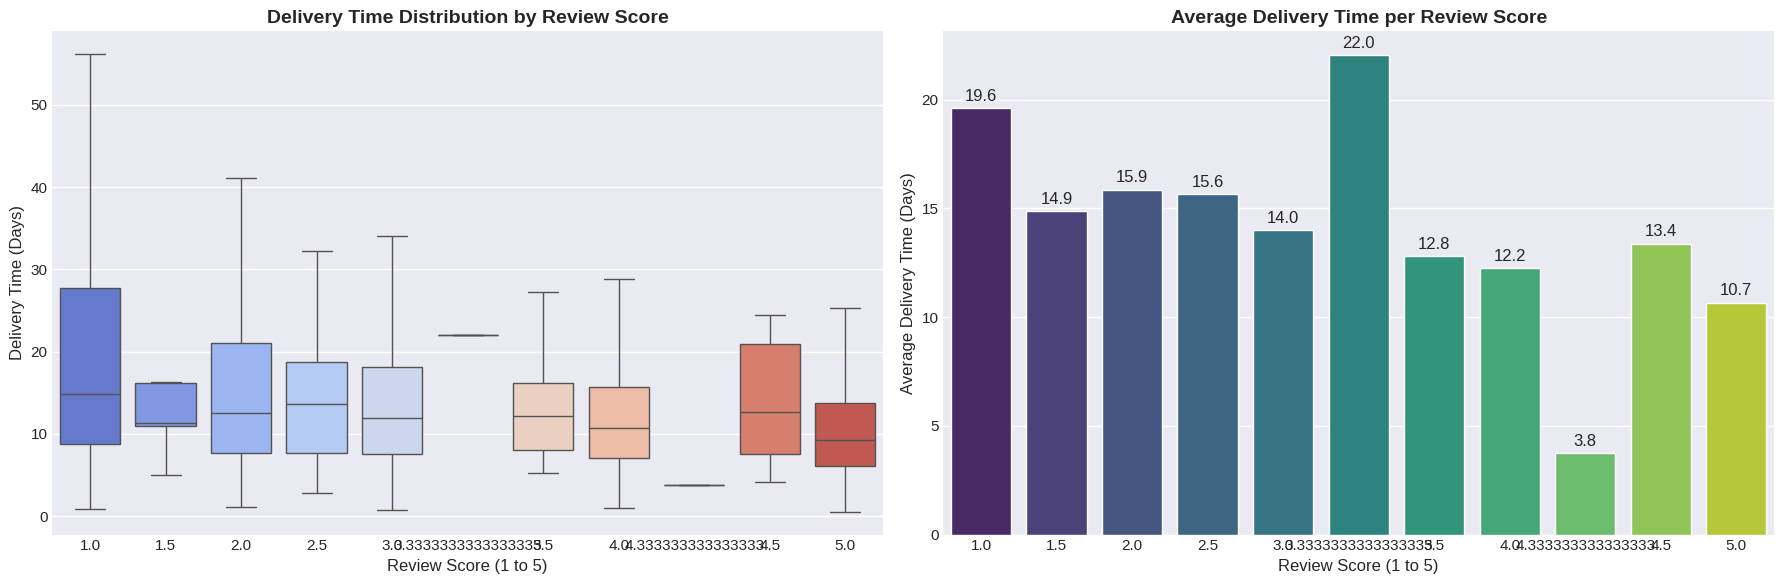

Correlation between Delivery Time and Review Score: -0.304
Insight: There is a negative correlation. As delivery time increases, the review score tends to decrease.


In [72]:
# ============================================================================
# Bivariate Analysis: How does 'Delivery Time' Affect the 'Review Score'?
# ============================================================================

# Drop missing values to ensure accurate plotting and correlation calculations
plot_data = df.dropna(subset=['review_score', 'delivery_time_days'])

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Boxplot: Distribution of delivery times across different review scores
sns.boxplot(
    data=plot_data,
    x='review_score',
    y='delivery_time_days',
    palette='coolwarm',
    ax=axes[0],
    showfliers=False  # Hides extreme outliers for a cleaner visual
)
axes[0].set_title('Delivery Time Distribution by Review Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Review Score (1 to 5)', fontsize=12)
axes[0].set_ylabel('Delivery Time (Days)', fontsize=12)

# 2. Barplot: Average delivery time for each review score
sns.barplot(
    data=plot_data,
    x='review_score',
    y='delivery_time_days',
    errorbar=None,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Average Delivery Time per Review Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Review Score (1 to 5)', fontsize=12)
axes[1].set_ylabel('Average Delivery Time (Days)', fontsize=12)

# Add data labels on top of the bars in the Barplot
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

# ============================================================================
# Statistical Correlation
# ============================================================================

# Calculate the Pearson correlation coefficient
correlation = plot_data['delivery_time_days'].corr(plot_data['review_score'])
print(f"Correlation between Delivery Time and Review Score: {correlation:.3f}")

# Interpretation logic
if correlation < 0:
    print("Insight: There is a negative correlation. As delivery time increases, the review score tends to decrease.")
else:
    print("Insight: There is no strong negative relationship observed.")

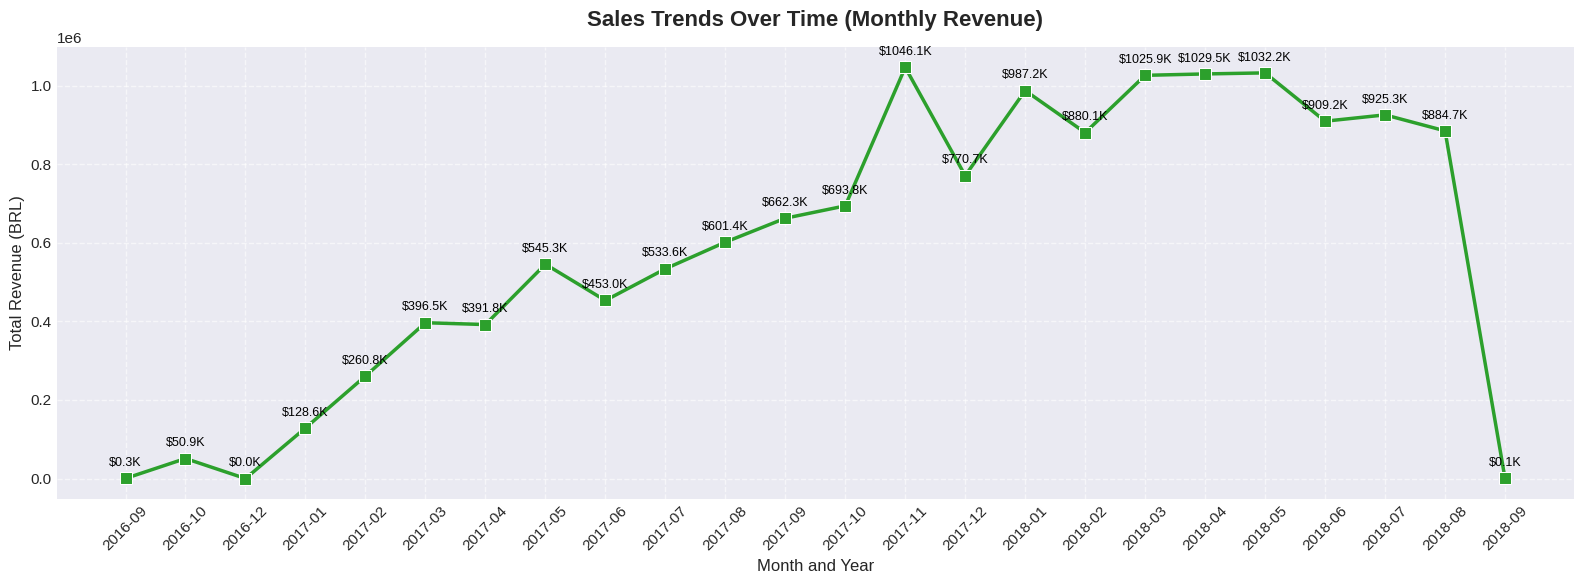

Insight: The highest revenue was generated in 2017-11 with a total of $1,046,127.84 BRL.


In [73]:
# ============================================================================
# Time Series Analysis: Sales Trends Over Time (Time vs. Revenue)
# ============================================================================

# 1. Ensure the purchase date column is in datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# 2. Extract Year and Month into a new column (e.g., '2017-08')
df['order_month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

# 3. Group by the Year-Month column and calculate the total revenue (sum of 'price')
# Note: We use 'price' to represent product revenue.
monthly_revenue = df.groupby('order_month_year')['price'].sum().reset_index(name='total_revenue')

# Convert the period to string so Seaborn can plot it correctly
monthly_revenue['order_month_year'] = monthly_revenue['order_month_year'].astype(str)

# 4. Plotting the trend using a Line Plot
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=monthly_revenue,
    x='order_month_year',
    y='total_revenue',
    marker='s',  # 's' stands for square markers
    color='#2ca02c',  # Green color for revenue/money
    linewidth=2.5,
    markersize=8
)

# 5. Formatting the chart
plt.title('Sales Trends Over Time (Monthly Revenue)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month and Year', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Adding text labels on top of each marker (Formatted in 'K' for Thousands)
max_revenue = monthly_revenue['total_revenue'].max()
for index, row in monthly_revenue.iterrows():
    # Convert revenue to thousands (K) for cleaner labels
    revenue_k = row['total_revenue'] / 1000

    # Adjust the Y position slightly above the marker based on the max value
    y_position = row['total_revenue'] + (max_revenue * 0.03)

    plt.text(row['order_month_year'], y_position,
             f"${revenue_k:.1f}K", color='black', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# Insight Generation
# ============================================================================
best_month = monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax()]
print(f"Insight: The highest revenue was generated in {best_month['order_month_year']} "
      f"with a total of ${best_month['total_revenue']:,.2f} BRL.")

## **3.3 Multivariate Analysis & Correlation (`Feature Importance`)**

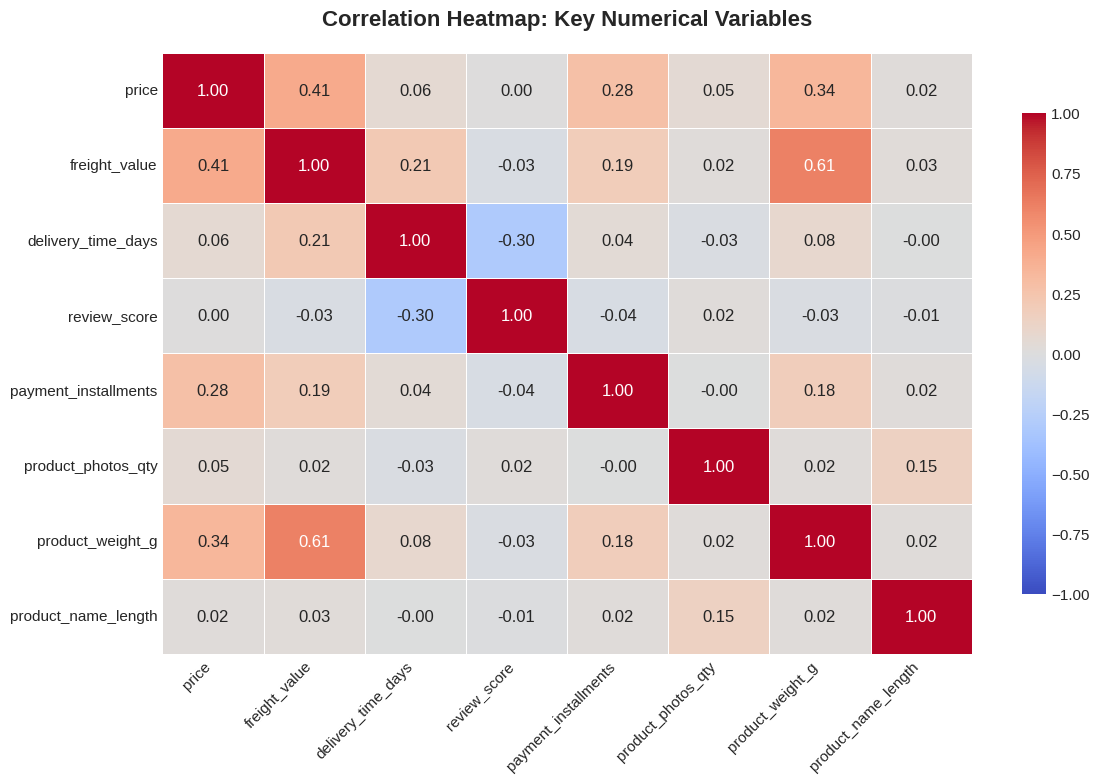

INSIGHTS: TOP CORRELATIONS
\n--- Variables Most Correlated with Customer Satisfaction (Review Score) ---
- delivery_time_days: -0.304
- payment_installments: -0.044
- freight_value: -0.034
- product_weight_g: -0.027
- product_photos_qty: 0.021
- product_name_length: -0.014
- price: 0.003
\n--- Variables Most Correlated with Revenue (Price) ---
- freight_value: 0.413
- product_weight_g: 0.341
- payment_installments: 0.281
- delivery_time_days: 0.061
- product_photos_qty: 0.053
- product_name_length: 0.020
- review_score: 0.003


In [74]:
# ============================================================================
# Multivariate Analysis: Which Numerical Variables are Most Strongly Correlated
# with Customer Satisfaction (Review Score) or Revenue (Price)?
# ============================================================================

# 1. Define the key numerical columns you want to analyze
# (These represent Revenue, Satisfaction, Logistics, and Product details)
numerical_cols = [
    'price',                  # Represents Revenue per item
    'freight_value',          # Shipping cost
    'delivery_time_days',     # Logistics performance
    'review_score',           # Customer Satisfaction
    'payment_installments',   # Customer purchasing behavior
    'product_photos_qty',     # Product presentation
    'product_weight_g',       # Product physical attribute
    'product_name_length'     # Product description attribute
]

# Ensure we only use columns that actually exist in your merged DataFrame 'df'
available_cols = [col for col in numerical_cols if col in df.columns]

# Create a subset of the data and drop missing values for accurate correlation calculation
corr_data = df[available_cols].dropna()

# 2. Calculate the Pearson Correlation Matrix
correlation_matrix = corr_data.corr()

# 3. Plotting the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,              # Display the correlation coefficients on the map
    cmap='coolwarm',         # Color map: Red = Positive, Blue = Negative
    fmt=".2f",               # Format numbers to 2 decimal places
    linewidths=0.5,          # Add lines between cells for better readability
    vmin=-1, vmax=1,         # Standard scale for Pearson correlation
    cbar_kws={'shrink': .8}  # Resize the colorbar slightly
)

# Formatting the Heatmap
plt.title('Correlation Heatmap: Key Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# ============================================================================
# Insight Extraction: Automatically printing the strongest correlations
# ============================================================================

print("="*60)
print("INSIGHTS: TOP CORRELATIONS")
print("="*60)

# Extract correlations related to Customer Satisfaction (Review Score)
if 'review_score' in correlation_matrix.columns:
    print("\\n--- Variables Most Correlated with Customer Satisfaction (Review Score) ---")
    review_corr = correlation_matrix['review_score'].drop('review_score')
    # Sort by absolute values to show the strongest relationships (positive or negative) first
    review_corr_sorted = review_corr.abs().sort_values(ascending=False)
    for col in review_corr_sorted.index:
        print(f"- {col}: {review_corr[col]:.3f}")

# Extract correlations related to Revenue (Price)
if 'price' in correlation_matrix.columns:
    print("\\n--- Variables Most Correlated with Revenue (Price) ---")
    price_corr = correlation_matrix['price'].drop('price')
    price_corr_sorted = price_corr.abs().sort_values(ascending=False)
    for col in price_corr_sorted.index:
        print(f"- {col}: {price_corr[col]:.3f}")

#customer segemtion
# New Section

In [75]:
print(df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_score',
       'review_comment_title', 'review_comment_message', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'product_category_name', 'product_name_length',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'day_of_week_int', 'hour', 'month', 'year', 'date',
       'delivery_time_days', 'product_category_name_english',
       'simplified_category', 'month_year',

In [76]:
# 1. Set the anchor date to 1 day AFTER the most recent purchase in the entire dataset
# This ensures our best, most recent customer has a Recency of 1 day, not 0 days.
anchor_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [77]:
# 2. Calculate RFM in a SINGLE, highly optimized step
# We sum 'price' and 'freight_value' safely at the item level to avoid duplicating order totals
df_rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (anchor_date - x.max()).days,  # Recency
    'order_id': 'nunique',                                               # Frequency (Unique Orders!)
    'price': 'sum',                                                      # Monetary (Item Value)
    'freight_value': 'sum'                                               # Monetary (Shipping Value)
})

In [78]:
# 3. Combine price and freight to get the true Total Monetary Value
df_rfm['Monetary'] = df_rfm['price'] + df_rfm['freight_value']

In [79]:
# 4. Clean up columns and rename them to standard RFM naming conventions
df_rfm.drop(columns=['price', 'freight_value'], inplace=True)
df_rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency'
}, inplace=True)

In [80]:
print(df_rfm.head())

                                  Recency  Frequency  Monetary
customer_unique_id                                            
0000366f3b9a7992bf8c76cfdf3221e2      116          1    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     27.19
0000f46a3911fa3c0805444483337064      542          1     86.22
0000f6ccb0745a6a4b88665a16c9f078      326          1     43.62
0004aac84e0df4da2b147fca70cf8255      293          1    196.89


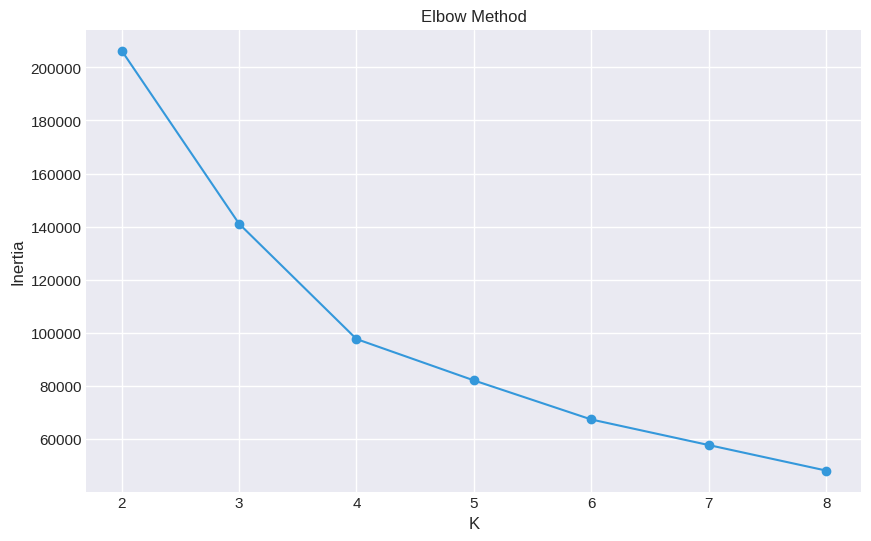

In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm[['Recency', 'Frequency', 'Monetary']])

# Elbow
inertias = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(2, 9), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ==========================================
# 1. SCORING LOGIC
# ==========================================
# Recency: Lower is better (5 = most recent)
df_rfm["R_Score"] = pd.qcut(df_rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Monetary: Higher is better (5 = biggest spenders)
df_rfm["M_Score"] = pd.qcut(df_rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Frequency: Higher is better (5 = most frequent). Using 'rank' to prevent bin overlap.
df_rfm["F_Score"] = pd.qcut(df_rfm["Frequency"].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# ==========================================
# 2. SEGMENT MAPPING (4 Clusters based on Elbow Method)
# ==========================================
segment_map = {
    # VIPs
    (5, 5): 'VIP', (5, 4): 'VIP', (4, 5): 'VIP', (4, 4): 'VIP',

    # Potential Loyalists
    (5, 3): 'Potential Loyalists', (5, 2): 'Potential Loyalists', (5, 1): 'Potential Loyalists',
    (4, 3): 'Potential Loyalists', (4, 2): 'Potential Loyalists', (4, 1): 'Potential Loyalists',
    (3, 3): 'Potential Loyalists', (3, 4): 'Potential Loyalists', (3, 5): 'Potential Loyalists',

    # At Risk
    (3, 2): 'At Risk', (3, 1): 'At Risk',
    (2, 5): 'At Risk', (2, 4): 'At Risk', (2, 3): 'At Risk', (2, 2): 'At Risk', (2, 1): 'At Risk',

    # Inactive
    (1, 5): 'Inactive', (1, 4): 'Inactive', (1, 3): 'Inactive', (1, 2): 'Inactive', (1, 1): 'Inactive'
}

# Apply the mapping with a fail-safe
df_rfm['Segment'] = df_rfm.apply(lambda x: segment_map.get((x['R_Score'], x['F_Score']), 'Need Attention'), axis=1)

# Create Group IDs and Total Scores
df_rfm["RFM_Group"] = df_rfm["R_Score"].astype(str) + df_rfm["F_Score"].astype(str) + df_rfm["M_Score"].astype(str)
df_rfm["RFM_Total_Score"] = df_rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

# View Results
print("--- Customer Segments ---")
print(df_rfm['Segment'].value_counts())

--- Customer Segments ---
Segment
Potential Loyalists    34478
At Risk                26703
Inactive               18962
VIP                    15277
Name: count, dtype: int64


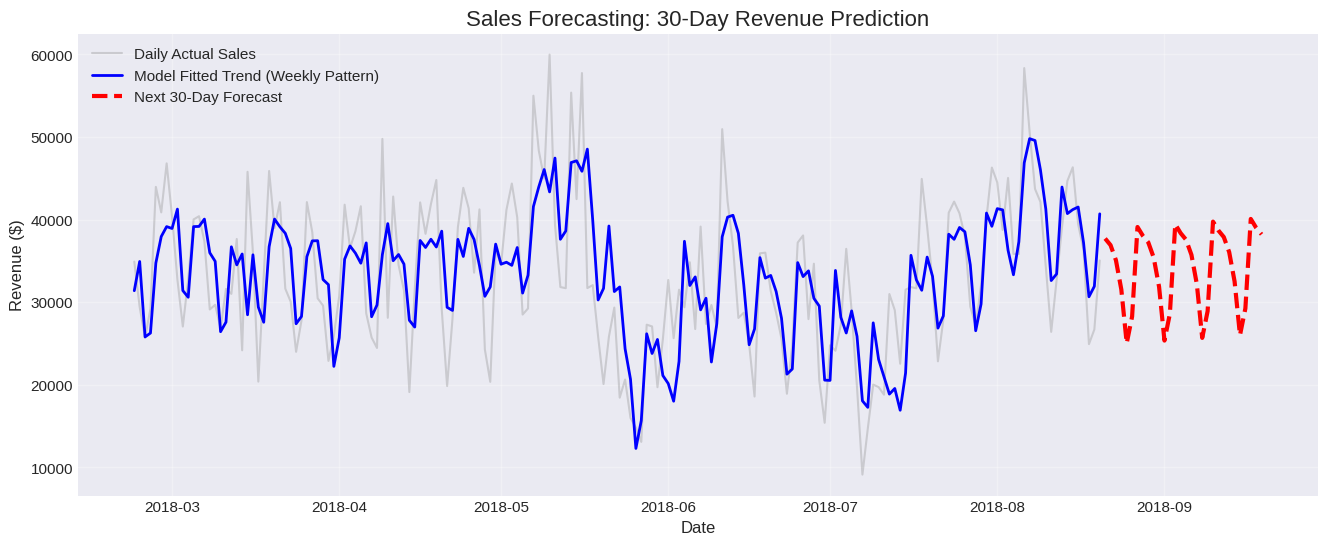

In [83]:
# ==========================================
# 3. TIME SERIES PREPARATION
# ==========================================
# Ensure datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Set index and resample to Daily Revenue
df_time = df.set_index('order_purchase_timestamp')
daily_sales = df_time['price'].resample('D').sum().to_frame()

# Fill missing days with 0
daily_sales = daily_sales.fillna(0)

# Calculate Moving Averages for historical context
daily_sales['7_day_MA'] = daily_sales['price'].rolling(window=7).mean()
daily_sales['30_day_MA'] = daily_sales['price'].rolling(window=30).mean()

# ==========================================
# 4. DATA CLEANING & FORECASTING MODEL
# ==========================================
# 1. Manually set the cutoff to avoid the "trickle" days at the end of the dataset
cutoff_date = '2018-08-20'

# 2. Trim the dataset cleanly
daily_sales_clean = daily_sales.loc[:cutoff_date].copy()

# 3. Fit the model on this healthy data
model_seasonal = ExponentialSmoothing(
    daily_sales_clean['price'],
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    initialization_method="estimated"
)
fit_model = model_seasonal.fit()

# Predict the next 30 days
forecast_steps = 30
forecast = fit_model.forecast(forecast_steps)

# Prevent impossible negative revenue predictions (The Safety Net)
forecast = forecast.clip(lower=0)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(16, 6))

# Define how much history to show (e.g., last 6 months)
lookback_days = 180

# Plot the recent actuals
plt.plot(daily_sales_clean.index[-lookback_days:],
         daily_sales_clean['price'][-lookback_days:],
         alpha=0.3, label='Daily Actual Sales', color='gray')

# Plot the Model's historical fit
plt.plot(daily_sales_clean.index[-lookback_days:],
         fit_model.fittedvalues[-lookback_days:],
         label='Model Fitted Trend (Weekly Pattern)', color='blue', linewidth=2)

# Plot the Future Forecast
plt.plot(forecast.index,
         forecast,
         label='Next 30-Day Forecast', color='red', linewidth=3, linestyle='--')

plt.title('Sales Forecasting: 30-Day Revenue Prediction', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

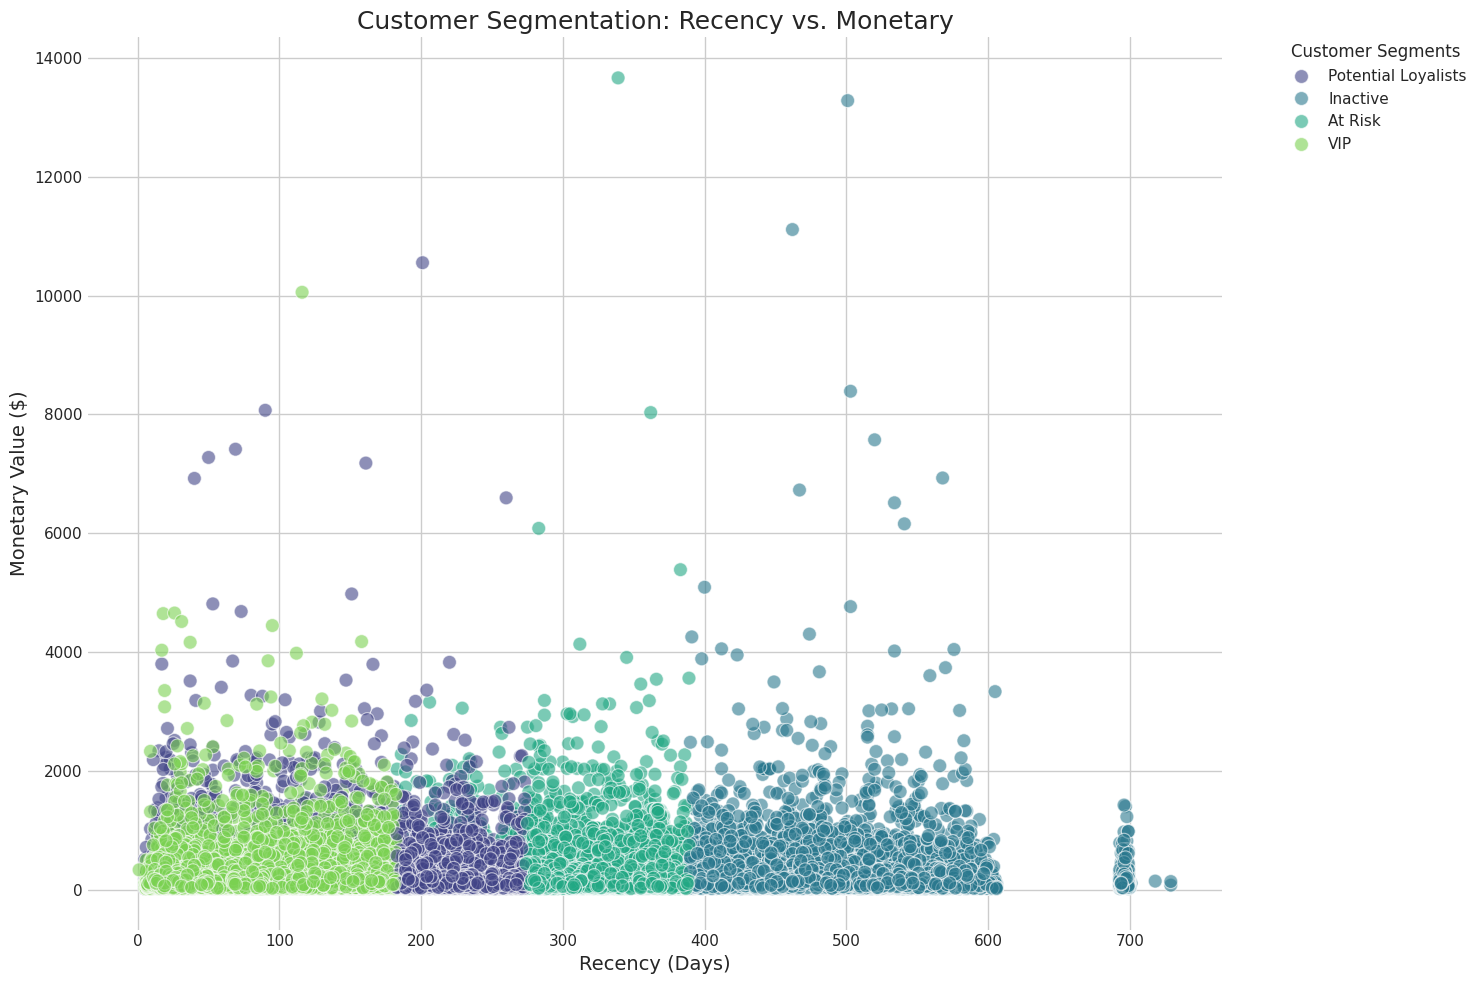

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

# 2. Create the scatter plot
# x = Recency (Days since last purchase)
# y = Monetary (Total spend)
# hue = Segment (Coloring the points by their group)
scatter = sns.scatterplot(
    data=df_rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='viridis',
    s=100,      # Base size of points
    alpha=0.6   # Transparency to see overlapping points
)

# 3. Enhance the plot for BI presentation
plt.title('Customer Segmentation: Recency vs. Monetary', fontsize=18)
plt.xlabel('Recency (Days)', fontsize=14)
plt.ylabel('Monetary Value ($)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Customer Segments')

# 4. Optional: Log scale for Y-axis if Monetary values have extreme outliers
# plt.yscale('log')

plt.tight_layout()
plt.show()

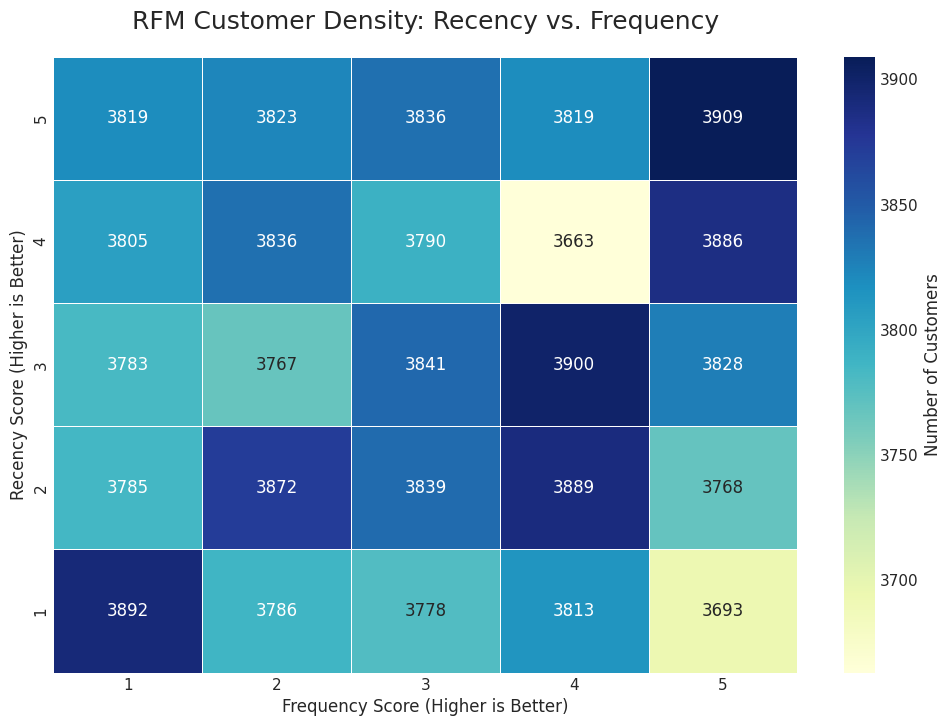

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a Pivot Table of the counts of customers
# This shows how many customers fall into each R vs F bucket
heatmap_data = df_rfm.groupby(['R_Score', 'F_Score']).size().unstack(fill_value=0)

# 2. Sort the index so 5 (Best) is at the top
heatmap_data = heatmap_data.sort_index(ascending=False)

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,          # Show the actual number of customers in each box
    fmt='d',             # Format as integers
    cmap='YlGnBu',       # Professional color gradient
    linewidths=.5,
    cbar_kws={'label': 'Number of Customers'}
)

# 4. Formatting
plt.title('RFM Customer Density: Recency vs. Frequency', fontsize=18, pad=20)
plt.xlabel('Frequency Score (Higher is Better)', fontsize=12)
plt.ylabel('Recency Score (Higher is Better)', fontsize=12)

plt.show()

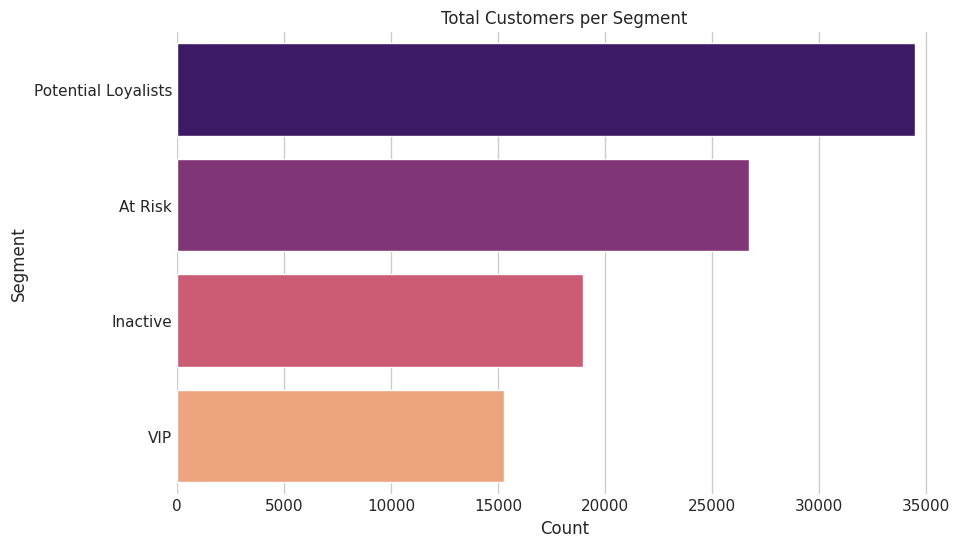

In [86]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_rfm,
              y='Segment',
              order=df_rfm['Segment'].value_counts().index,
              palette='magma')

plt.title('Total Customers per Segment')
plt.xlabel('Count')
plt.ylabel('Segment')
sns.despine()
plt.show()

In [87]:
# 1. Ensure the index is a DatetimeIndex
df_time = df.set_index('order_purchase_timestamp')

# 2. Resample to Daily Revenue (Sum of price)
# 'D' stands for Daily. You can use 'W' for Weekly.
daily_sales = df_time['price'].resample('D').sum().to_frame()

# Handle any missing days (e.g., if no sales happened on a Tuesday) by filling with 0
daily_sales = daily_sales.fillna(0)

In [88]:
# 7-Day Moving Average
daily_sales['7_day_MA'] = daily_sales['price'].rolling(window=7).mean()

# 30-Day Moving Average
daily_sales['30_day_MA'] = daily_sales['price'].rolling(window=30).mean()

In [89]:
# Import the forecasting model from statsmodels
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fit the Forecasting Model
# We use an 'additive' trend. If your data has strong weekly seasonality,
# you could add seasonal='add' and seasonal_periods=7.
model = ExponentialSmoothing(
    daily_sales['price'],
    trend='add',
    seasonal=None,
    initialization_method="estimated"
)
fit_model = model.fit()

In [90]:
# 2. Predict the Next 30 Days
forecast_steps = 30
forecast = fit_model.forecast(forecast_steps)

In [91]:
# 1. Find the very last day where a real sale occurred (price > 0)
last_active_date = daily_sales[daily_sales['price'] > 0].index.max()

# 2. Trim the dataframe to remove the trailing zeros at the end of the dataset
daily_sales_clean = daily_sales.loc[:last_active_date]

# 3. Now, feed THIS clean data into your model
model_seasonal = ExponentialSmoothing(
    daily_sales_clean['price'],  # <-- Use the cleaned data here
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    initialization_method="estimated"
)
fit_model_seasonal = model_seasonal.fit()

# ... proceed with predicting and plotting as usual

# **Exporting Data into Star Schema Tables for Power BI (Keeping All Duplicates)**

In [92]:
# ============================================================================
# Exporting Data into Star Schema Tables for Power BI (Keeping All Duplicates)
# ============================================================================

# 1. Dim_Customers: Customer information
dim_customers = df[[
    'customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
    'customer_city', 'customer_state'
]]

# 2. Dim_Products: Product attributes and engineered features
dim_products = df[[
    'product_id', 'product_category_name', 'product_category_name_english',
    'simplified_category', 'product_name_length', 'product_description_lenght',
    'product_photos_qty', 'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm', 'product_volume_cm3'
]]

# 3. Dim_Sellers: Seller details
dim_sellers = df[[
    'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'
]]

# 4. Fact_Orders: The main transaction table with delivery metrics
fact_orders = df[[
    'order_id', 'customer_id', 'order_status',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'delivery_time_days',
    'actual_delivery_days', 'delivery_time_winsorized', 'delivery_delay_days',
    'is_delivered', 'is_late', 'purchase_year', 'purchase_month',
    'purchase_day_of_week', 'is_weekend', 'day_of_week_int', 'hour',
    'month', 'year', 'Day_of_Week', 'order_month_year'
]]

# 5. Fact_Order_Items: Granular items details (Price and Freight)
fact_order_items = df[[
    'order_id', 'order_item_id', 'product_id', 'seller_id',
    'shipping_limit_date', 'price', 'freight_value', 'freight_ratio'
]]

# 6. Fact_Order_Payments: Payment behavior
fact_order_payments = df[[
    'order_id', 'payment_sequential', 'payment_type',
    'payment_installments', 'payment_value'
]]

# 7. Fact_Order_Reviews: Customer satisfaction and sentiment
fact_order_reviews = df[[
    'order_id', 'review_score', 'review_comment_title',
    'review_comment_message', 'is_vocal_customer', 'satisfaction_class'
]]

# --- Exporting to CSV ---
dim_customers.to_csv('dim_customers.csv', index=False)
dim_products.to_csv('dim_products.csv', index=False)
dim_sellers.to_csv('dim_sellers.csv', index=False)
fact_orders.to_csv('fact_orders.csv', index=False)
fact_order_items.to_csv('fact_order_items.csv', index=False)
fact_order_payments.to_csv('fact_order_payments.csv', index=False)
fact_order_reviews.to_csv('fact_order_reviews.csv', index=False)

print("All tables have been successfully exported without removing any duplicates!")

All tables have been successfully exported without removing any duplicates!


In [93]:
# 1. Handling the Geolocation Table (Assuming your dataframe is named 'df_geo')
# We must aggregate coordinates to have ONE unique row per zip_code_prefix
# This solves the connection problem in Power BI.
dim_geolocation_unique = df_geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first', # Keep the first city name associated
    'geolocation_state': 'first' # Keep the first state name associated
}).reset_index()

In [94]:
dim_geolocation_unique.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.55,-46.63,sao paulo,SP
1,1002,-23.55,-46.63,sao paulo,SP
2,1003,-23.55,-46.64,sao paulo,SP
3,1004,-23.55,-46.63,sao paulo,SP
4,1005,-23.55,-46.64,sao paulo,SP


In [95]:
# 2. Preparing the Customer Table with Geo-Data
# We merge the unique coordinates into the customers dataframe
dim_customers_geo = pd.merge(
    dim_customers, # The table we created in the previous step
    dim_geolocation_unique,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

In [96]:
dim_customers_geo.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
geolocation_zip_code_prefix,312
geolocation_lat,312
geolocation_lng,312
geolocation_city,312
geolocation_state,312


In [97]:
# 3. Preparing the Seller Table with Geo-Data
# We merge the unique coordinates into the sellers dataframe
dim_sellers_geo = pd.merge(
    dim_sellers, # The table we created in the previous step
    dim_geolocation_unique,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

In [98]:
dim_sellers_geo.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0
geolocation_zip_code_prefix,261
geolocation_lat,261
geolocation_lng,261
geolocation_city,261
geolocation_state,261


In [100]:
# ============================================================================
# Handling Missing Values in Geolocation after Merge
# Strategy: Fill missing cities/states from original columns,
# then impute missing coordinates using city averages.
# ============================================================================

# 1. Fill missing categorical data (City and State) using the original columns
# For Customers
dim_customers_geo['geolocation_city'] = dim_customers_geo['geolocation_city'].fillna(dim_customers_geo['customer_city'])
dim_customers_geo['geolocation_state'] = dim_customers_geo['geolocation_state'].fillna(dim_customers_geo['customer_state'])

# For Sellers
dim_sellers_geo['geolocation_city'] = dim_sellers_geo['geolocation_city'].fillna(dim_sellers_geo['seller_city'])
dim_sellers_geo['geolocation_state'] = dim_sellers_geo['geolocation_state'].fillna(dim_sellers_geo['seller_state'])

# 2. Impute missing coordinates (Latitude and Longitude) using City averages
# Create a dictionary mapping each city to its average coordinates
city_coords = df_geolocation.groupby('geolocation_city')[['geolocation_lat', 'geolocation_lng']].mean()

lat_mapping = city_coords['geolocation_lat'].to_dict()

lng_mapping = city_coords['geolocation_lng'].to_dict()


# Map the averages to the missing values based on the city
dim_customers_geo['geolocation_lat'] = dim_customers_geo['geolocation_lat'].fillna(dim_customers_geo['customer_city'].map(lat_mapping))

dim_customers_geo['geolocation_lng'] = dim_customers_geo['geolocation_lng'].fillna(dim_customers_geo['customer_city'].map(lng_mapping))


dim_sellers_geo['geolocation_lat'] = dim_sellers_geo['geolocation_lat'].fillna(dim_sellers_geo['seller_city'].map(lat_mapping))

dim_sellers_geo['geolocation_lng'] = dim_sellers_geo['geolocation_lng'].fillna(dim_sellers_geo['seller_city'].map(lng_mapping))


# 3. Ultimate Fallback: Fill any remaining missing coordinates with the global average of Brazil
global_lat = df_geolocation['geolocation_lat'].mean()
global_lng = df_geolocation['geolocation_lng'].mean()


dim_customers_geo['geolocation_lat'] = dim_customers_geo['geolocation_lat'].fillna(global_lat)
dim_customers_geo['geolocation_lng'] = dim_customers_geo['geolocation_lng'].fillna(global_lng)

dim_sellers_geo['geolocation_lat'] = dim_sellers_geo['geolocation_lat'].fillna(global_lat)
dim_sellers_geo['geolocation_lng'] = dim_sellers_geo['geolocation_lng'].fillna(global_lng)


# 4. Verify that all missing values are handled
print("Missing values in Customers Geo table:")

print(dim_customers_geo[['geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']].isna().sum())

print("\\nMissing values in Sellers Geo table:")

print(dim_sellers_geo[['geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']].isna().sum())

# 5. Exporting the fully cleaned tables to CSV for Power BI
dim_customers_geo.to_csv('dim_customers_with_geo_cleaned.csv', index=False)
dim_sellers_geo.to_csv('dim_sellers_with_geo_cleaned.csv', index=False)

print("\\nCleaned Geo-Data has been exported successfully with ZERO missing values!")

Missing values in Customers Geo table:
geolocation_lat      0
geolocation_lng      0
geolocation_city     0
geolocation_state    0
dtype: int64
\nMissing values in Sellers Geo table:
geolocation_lat      0
geolocation_lng      0
geolocation_city     0
geolocation_state    0
dtype: int64
\nCleaned Geo-Data has been exported successfully with ZERO missing values!


In [103]:
dim_customers_geo.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0
geolocation_zip_code_prefix,312
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [102]:
dim_sellers_geo.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0
geolocation_zip_code_prefix,261
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [104]:
dim_customers_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117604 entries, 0 to 117603
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   customer_id                  117604 non-null  object 
 1   customer_unique_id           117604 non-null  object 
 2   customer_zip_code_prefix     117604 non-null  int64  
 3   customer_city                117604 non-null  object 
 4   customer_state               117604 non-null  object 
 5   geolocation_zip_code_prefix  117292 non-null  float64
 6   geolocation_lat              117604 non-null  float64
 7   geolocation_lng              117604 non-null  float64
 8   geolocation_city             117604 non-null  object 
 9   geolocation_state            117604 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 9.0+ MB


In [105]:
# 4. Exporting the new integrated tables to CSV
dim_geolocation_unique.to_csv('dim_geolocation_cleaned.csv', index=False)
dim_customers_geo.to_csv('dim_customers_with_geo.csv', index=False)
dim_sellers_geo.to_csv('dim_sellers_with_geo.csv', index=False)

print("Geo-Data has been integrated and exported successfully!")

Geo-Data has been integrated and exported successfully!
